# 📊 Zeitreihenprognose mit Prophet
## Demo: Rossmann Store Sales – Analyst-in-the-Loop

---

### 🧮 Die theoretische Basis: Die Prophet-Gleichung
Bevor wir in die Daten abtauchen, werfen wir einen kurzen Blick unter die Haube. Prophet basiert auf einem additiven (oder multiplikativen) Regressionsmodell. Die grundlegende Formel lautet:

$$y(t) = g(t) + s(t) + h(t) + \beta X(t) + \epsilon_t$$

* **$g(t)$ (Trend):** Bildet nicht-periodische Veränderungen ab (z.B. langfristiges Wachstum).
* **$s(t)$ (Saisonalität):** Greift periodische Veränderungen auf (wöchentliche, jährliche Muster).
* **$h(t)$ (Holidays/Feiertage):** Modelliert unregelmäßige, punktuelle Events.
* **$\beta X(t)$ (Regressoren):** Erlaubt die Einbindung externer Variablen (z.B. Promotionen, Wetter).
* **$\epsilon_t$ (Fehlerterm):** Das Rauschen, das unser Modell nicht erklären kann.

**Unser Ziel heute:** Wir werden uns ansehen, wie wir als Analysten direkt in $h(t)$ und $\beta X(t)$ eingreifen können, um das Modell massiv zu verbessern. 

---

### 🏪 Der Datensatz: Rossmann Drogeriemarkt
Wir nutzen historische Verkaufsdaten von Rossmann (Quelle: [Kaggle](https://www.kaggle.com/c/rossmann-store-sales)).
* 1.017.209 tägliche Umsatzbeobachtungen für **1.115 Filialen** in Deutschland
* Zeitraum: 01.01.2013 – 31.07.2015

### 🗺️ Zwei Filialen – zwei verschiedene Welten
Das Problem an generischen Modellen: Sie übersehen lokale Besonderheiten. Schauen wir uns zwei Filialen an Feiertagen an:

| Filiale | Typ | Ostersamstag | Ostermontag | 1. Mai |
|---|---|---|---|---|
| **530** | Ferienort-Filiale | ✅ offen, **2.6x Umsatz** | ✅ offen | ❌ geschlossen |
| **262** | Ferienort-Filiale | – | – | ✅ offen, **33.982€ Ø** |
| **16** | Normale Stadtfiliale | – | – | ❌ geschlossen, 0€ |

## 📦 1. Installation & Imports

In [ ]:
!pip install prophet matplotlib seaborn scikit-learn --quiet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Hilfsfunktionen Metriken
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rmspe(y_true, y_pred):
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2)) * 100

def print_metrics(y_true, y_pred, name):
    print(f'{name}:')
    print(f'  RMSE:  {rmse(y_true, y_pred):.0f} €')
    print(f'  RMSPE: {rmspe(y_true, y_pred):.1f}%')

print('✅ Alle Bibliotheken erfolgreich geladen!')

✅ Alle Bibliotheken erfolgreich geladen!


---
## 🔍 2. Explorative Datenanalyse (EDA)

In [4]:
train = pd.read_csv('../data/rossmann-store-sales/train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv('../data/rossmann-store-sales/store.csv')

print('📁 train.csv:', train.shape)
print('📁 store.csv:', store.shape)
train.head()

📁 train.csv: (1017209, 9)
📁 store.csv: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


### 2.1 Spalten verstehen

**train.csv** – eine Zeile = ein Tag + eine Filiale:

| Spalte | Bedeutung | Werte |
|---|---|---|
| `Store` | Filial-ID | 1 – 1115 |
| `Date` | Datum | 2013-01-01 bis 2015-07-31 |
| `Sales` | **Zielgröße: Tagesumsatz (€)** | 0 – ~40.000 |
| `Open` | War die Filiale geöffnet? | 0 = nein, 1 = ja |
| `Promo` | Lief eine Promotion? | 0 / 1 |
| `StateHoliday` | Art des Feiertags | **0** = kein, **a** = gesetzl. Feiertag, **b** = Ostern, **c** = Weihnachten |
| `SchoolHoliday` | Schulferien? | 0 / 1 |

> **🎯 Wichtige Erkenntnis:** Der Datensatz kodiert Feiertage aus Sicht der **Mehrheit der Filialen**.
> Insel-Filialen verhalten sich an Feiertagen komplett anders – das ist im Datensatz **nicht** sichtbar!
> Genau hier ist Analyst-in-the-Loop unverzichtbar.

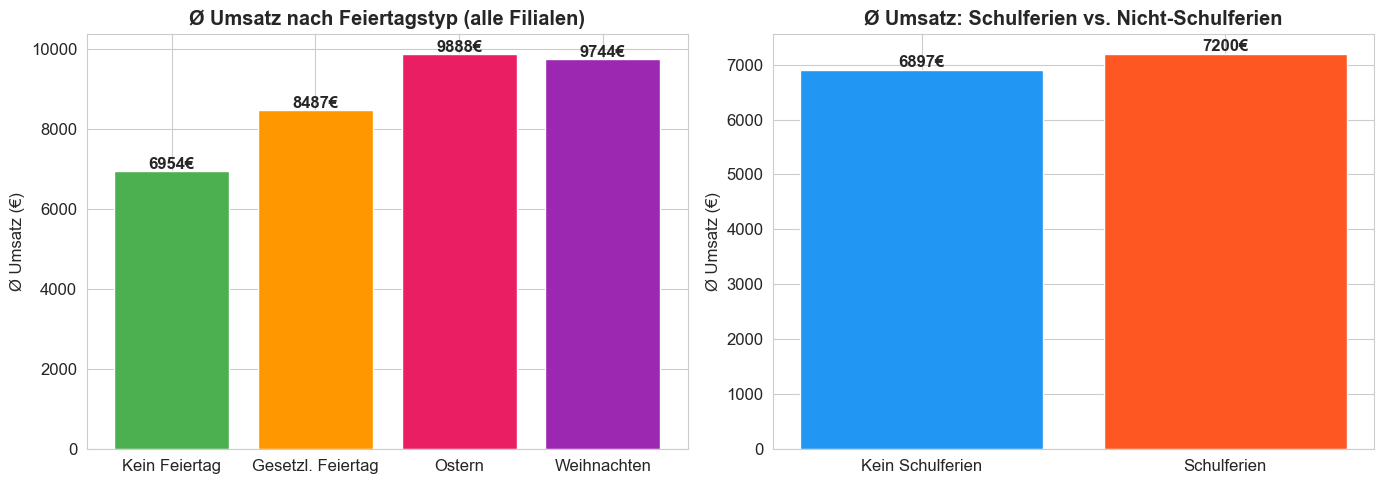

In [5]:
# Feiertags-Effekte im Gesamtdatensatz
df_open = train[train['Open'] == 1]

holiday_labels = {'0': 'Kein Feiertag', 'a': 'Gesetzl. Feiertag', 'b': 'Ostern', 'c': 'Weihnachten'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

holiday_sales = df_open.groupby('StateHoliday')['Sales'].mean()
colors = ['#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
bars = axes[0].bar([holiday_labels.get(k, k) for k in holiday_sales.index],
                   holiday_sales.values, color=colors[:len(holiday_sales)])
axes[0].set_title('Ø Umsatz nach Feiertagstyp (alle Filialen)', fontweight='bold')
axes[0].set_ylabel('Ø Umsatz (€)')
for bar, val in zip(bars, holiday_sales.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:.0f}€', ha='center', fontweight='bold')

school_sales = df_open.groupby('SchoolHoliday')['Sales'].mean()
axes[1].bar(['Kein Schulferien', 'Schulferien'], school_sales.values, color=['#2196F3', '#FF5722'])
axes[1].set_title('Ø Umsatz: Schulferien vs. Nicht-Schulferien', fontweight='bold')
axes[1].set_ylabel('Ø Umsatz (€)')
for i, val in enumerate(school_sales.values):
    axes[1].text(i, val + 50, f'{val:.0f}€', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

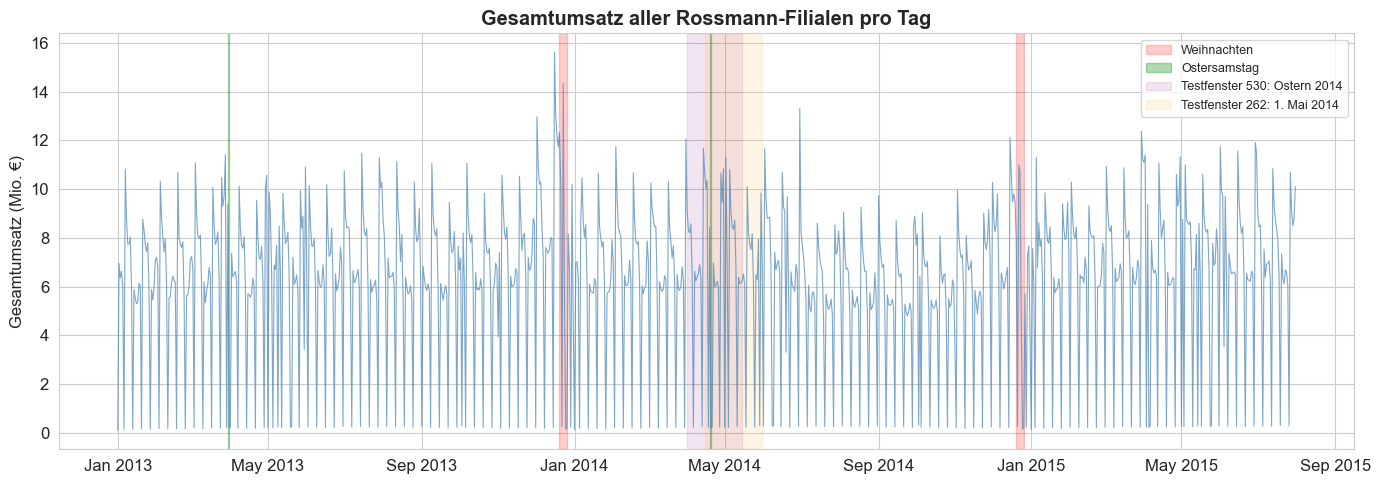

In [6]:
# Gesamtumsatz über Zeit
daily_total = train[train['Open'] == 1].groupby('Date')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_total['Date'], daily_total['Sales'] / 1e6, color='steelblue', alpha=0.7, linewidth=0.8)

for year in [2013, 2014]:
    ax.axvspan(pd.Timestamp(f'{year}-12-20'), pd.Timestamp(f'{year}-12-26'),
               alpha=0.2, color='red', label='Weihnachten' if year == 2013 else '')
for ostern_d in ['2013-03-30', '2014-04-19']:
    ax.axvspan(pd.Timestamp(ostern_d), pd.Timestamp(ostern_d) + pd.Timedelta(days=1),
               alpha=0.3, color='green', label='Ostersamstag' if ostern_d == '2013-03-30' else '')

# Testfenster Filiale 530 (Ostern)
ax.axvspan(pd.Timestamp('2014-04-01'), pd.Timestamp('2014-05-15'),
           alpha=0.1, color='purple', label='Testfenster 530: Ostern 2014')
# Testfenster Filiale 262 (1. Mai)
ax.axvspan(pd.Timestamp('2014-04-15'), pd.Timestamp('2014-05-31'),
           alpha=0.1, color='orange', label='Testfenster 262: 1. Mai 2014')

ax.set_title('Gesamtumsatz aller Rossmann-Filialen pro Tag', fontweight='bold')
ax.set_ylabel('Gesamtumsatz (Mio. €)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

---
## 🥚 3. Fall 1: Filiale 530 – Ostersamstag & Ostermontag am Ferienort

### Das Problem

Filiale 530 (vermutlich Ferienort/Insel) verhält sich an Ostern **komplett anders** als der Datensatz suggeriert:

| Tag | StateHoliday | Normalfiliale | Filiale 530 |
|---|---|---|---|
| Karfreitag | `b` | ❌ geschlossen | ❌ geschlossen |
| **Ostersamstag** | **`0`** ❗ | normal ~5.500€ | **~11.000€ (2.6x!)** |
| Ostersonntag | `0` | geschlossen | geschlossen |
| **Ostermontag** | **`b`** ❗ | ❌ geschlossen | **✅ offen ~5.300€** |

**Zwei unsichtbare Effekte:**
1. Ostersamstag: `StateHoliday='0'` aber 2.6x Umsatz – Touristen kaufen vor dem langen Wochenende
2. Ostermontag: `StateHoliday='b'` aber offen – Prophet würde Schließung vorhersagen

Filiale 530:
Training: 2013-01-01 – 2014-03-31 (438 Tage)
Test:     2014-04-01 – 2014-05-15 (43 Tage)


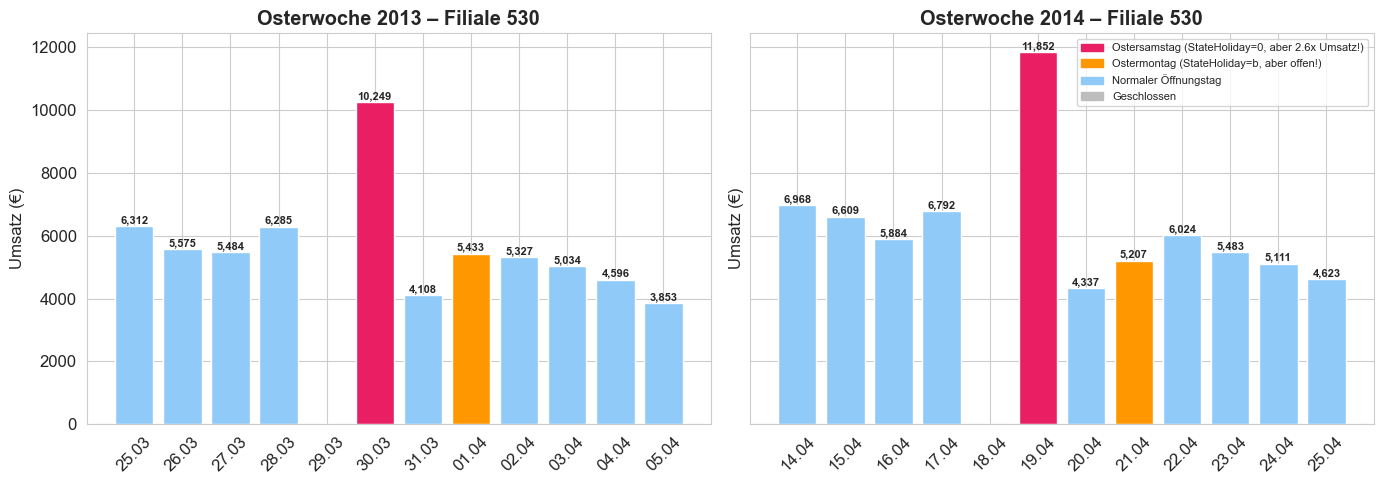

🔑 Beide Effekte sind im Datensatz UNSICHTBAR – reines Analyst-Wissen!


In [5]:
STORE_530 = 530
CUTOFF_530   = '2014-04-01'
TEST_END_530 = '2014-05-15'

df_530 = train[train['Store'] == STORE_530].copy().sort_values('Date').reset_index(drop=True)

df_train_530 = df_530[(df_530['Date'] < CUTOFF_530) & (df_530['Open'] == 1)]
df_test_530  = df_530[(df_530['Date'] >= CUTOFF_530) & (df_530['Date'] <= TEST_END_530) & (df_530['Open'] == 1)]

print(f'Filiale {STORE_530}:')
print(f'Training: {df_train_530["Date"].min().date()} – {df_train_530["Date"].max().date()} ({len(df_train_530)} Tage)')
print(f'Test:     {df_test_530["Date"].min().date()} – {df_test_530["Date"].max().date()} ({len(df_test_530)} Tage)')

# Osterwochen visualisieren
oster_530 = df_530[
    (df_530['Date'] >= '2013-03-25') & (df_530['Date'] <= '2013-04-05') |
    (df_530['Date'] >= '2014-04-14') & (df_530['Date'] <= '2014-04-25')
].copy()
oster_530['Jahr'] = oster_530['Date'].dt.year
oster_530['Tag']  = oster_530['Date'].dt.strftime('%d.%m')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (jahr, gruppe) in zip(axes, oster_530.groupby('Jahr')):
    farben = ['#E91E63' if s == 0 and gruppe[gruppe['Date'] == d]['Date'].dt.dayofweek.values[0] == 5
              else '#4CAF50' if s == 'b' else 'steelblue'
              for d, s in zip(gruppe['Date'], gruppe['StateHoliday'])]
    bars = ax.bar(gruppe['Tag'], gruppe['Sales'], color=[
        '#E91E63' if (row['Open'] == 1 and row['Date'].dayofweek == 5 and row['StateHoliday'] == '0')
        else '#FF9800' if (row['Open'] == 1 and row['StateHoliday'] == 'b')
        else '#90CAF9' if row['Open'] == 1
        else '#BDBDBD'
        for _, row in gruppe.iterrows()
    ])
    ax.set_title(f'Osterwoche {jahr} – Filiale {STORE_530}', fontweight='bold')
    ax.set_ylabel('Umsatz (€)')
    ax.tick_params(axis='x', rotation=45)
    for bar, (_, row) in zip(bars, gruppe.iterrows()):
        if row['Sales'] > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                    f"{row['Sales']:,.0f}", ha='center', fontsize=8, fontweight='bold')

# Legende
from matplotlib.patches import Patch
legend = [
    Patch(color='#E91E63', label='Ostersamstag (StateHoliday=0, aber 2.6x Umsatz!)'),
    Patch(color='#FF9800', label='Ostermontag (StateHoliday=b, aber offen!)'),
    Patch(color='#90CAF9', label='Normaler Öffnungstag'),
    Patch(color='#BDBDBD', label='Geschlossen'),
]
axes[1].legend(handles=legend, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()
print('🔑 Beide Effekte sind im Datensatz UNSICHTBAR – reines Analyst-Wissen!')

In [6]:
# Feiertage definieren
feiertage_a = train[train['StateHoliday'] == 'a'][['Date']].drop_duplicates().rename(columns={'Date': 'ds'})
feiertage_a['holiday'] = 'gesetzlicher_feiertag'

weihnachten = train[train['StateHoliday'] == 'c'][['Date']].drop_duplicates().rename(columns={'Date': 'ds'})
weihnachten['holiday'] = 'weihnachten'

schulferien = train[train['SchoolHoliday'] == 1][['Date']].drop_duplicates().rename(columns={'Date': 'ds'})
schulferien['holiday'] = 'schulferien'

# Ostern (StateHoliday='b') – aber Ostermontag bei Filiale 530 ist offen!
# Wir behalten 'b' für Karfreitag (geschlossen), Ostermontag behandeln wir separat
karfreitag = pd.DataFrame({
    'ds': pd.to_datetime(['2013-03-29', '2014-04-18']),
    'holiday': 'karfreitag'
})

# 🎯 ANALYST-WISSEN 1: Ostersamstag – StateHoliday='0' aber 2.6x Umsatz!
ostersamstag = pd.DataFrame({
    'ds': pd.to_datetime(['2013-03-30', '2014-04-19']),
    'holiday': 'ostersamstag'
})

# 🎯 ANALYST-WISSEN 2: Ostermontag – StateHoliday='b' aber Filiale 530 hat GEÖFFNET!
# Wir definieren ihn als eigenen positiven Effekt statt als Schließtag
ostermontag_insel = pd.DataFrame({
    'ds': pd.to_datetime(['2013-04-01', '2014-04-21']),
    'holiday': 'ostermontag_insel'
})

# Baseline Holidays (ohne Analyst-Wissen)
ostern_standard = train[train['StateHoliday'] == 'b'][['Date']].drop_duplicates().rename(columns={'Date': 'ds'})
ostern_standard['holiday'] = 'ostern'
holidays_baseline = pd.concat([feiertage_a, ostern_standard, weihnachten, schulferien], ignore_index=True)

# Expert Holidays (mit Analyst-Wissen)
holidays_expert = pd.concat([
    feiertage_a, karfreitag, ostersamstag, ostermontag_insel, weihnachten, schulferien
], ignore_index=True)

print('Holidays Baseline:', holidays_baseline['holiday'].value_counts().to_dict())
print('Holidays Expert: ', holidays_expert['holiday'].value_counts().to_dict())
print()
print('🎯 Expert-Modell kennt:')
print('   ostersamstag     → StateHoliday=0, aber Boom-Tag')
print('   ostermontag_insel → StateHoliday=b, aber geöffnet mit positivem Effekt')

Holidays Baseline: {'schulferien': 478, 'gesetzlicher_feiertag': 27, 'ostern': 6, 'weihnachten': 4}
Holidays Expert:  {'schulferien': 478, 'gesetzlicher_feiertag': 27, 'weihnachten': 4, 'karfreitag': 2, 'ostermontag_insel': 2, 'ostersamstag': 2}

🎯 Expert-Modell kennt:
   ostersamstag     → StateHoliday=0, aber Boom-Tag
   ostermontag_insel → StateHoliday=b, aber geöffnet mit positivem Effekt


In [7]:
# Prophet Format
prophet_train_530 = df_train_530[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
prophet_test_530  = df_test_530[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

# Baseline
print('Trainiere Baseline...')
m_base_530 = Prophet(holidays=holidays_baseline, yearly_seasonality=True,
                     weekly_seasonality=True, interval_width=0.80)
m_base_530.fit(prophet_train_530)
fc_base_530 = m_base_530.predict(prophet_test_530[['ds']])

# Expert
print('Trainiere Expert...')
m_expert_530 = Prophet(holidays=holidays_expert, yearly_seasonality=True,
                       weekly_seasonality=True, interval_width=0.80)
m_expert_530.fit(prophet_train_530)
fc_expert_530 = m_expert_530.predict(prophet_test_530[['ds']])

print('✅ Beide Modelle trainiert!')

12:43:12 - cmdstanpy - INFO - Chain [1] start processing


Trainiere Baseline...


12:43:12 - cmdstanpy - INFO - Chain [1] done processing
12:43:12 - cmdstanpy - INFO - Chain [1] start processing
12:43:12 - cmdstanpy - INFO - Chain [1] done processing


Trainiere Expert...
✅ Beide Modelle trainiert!


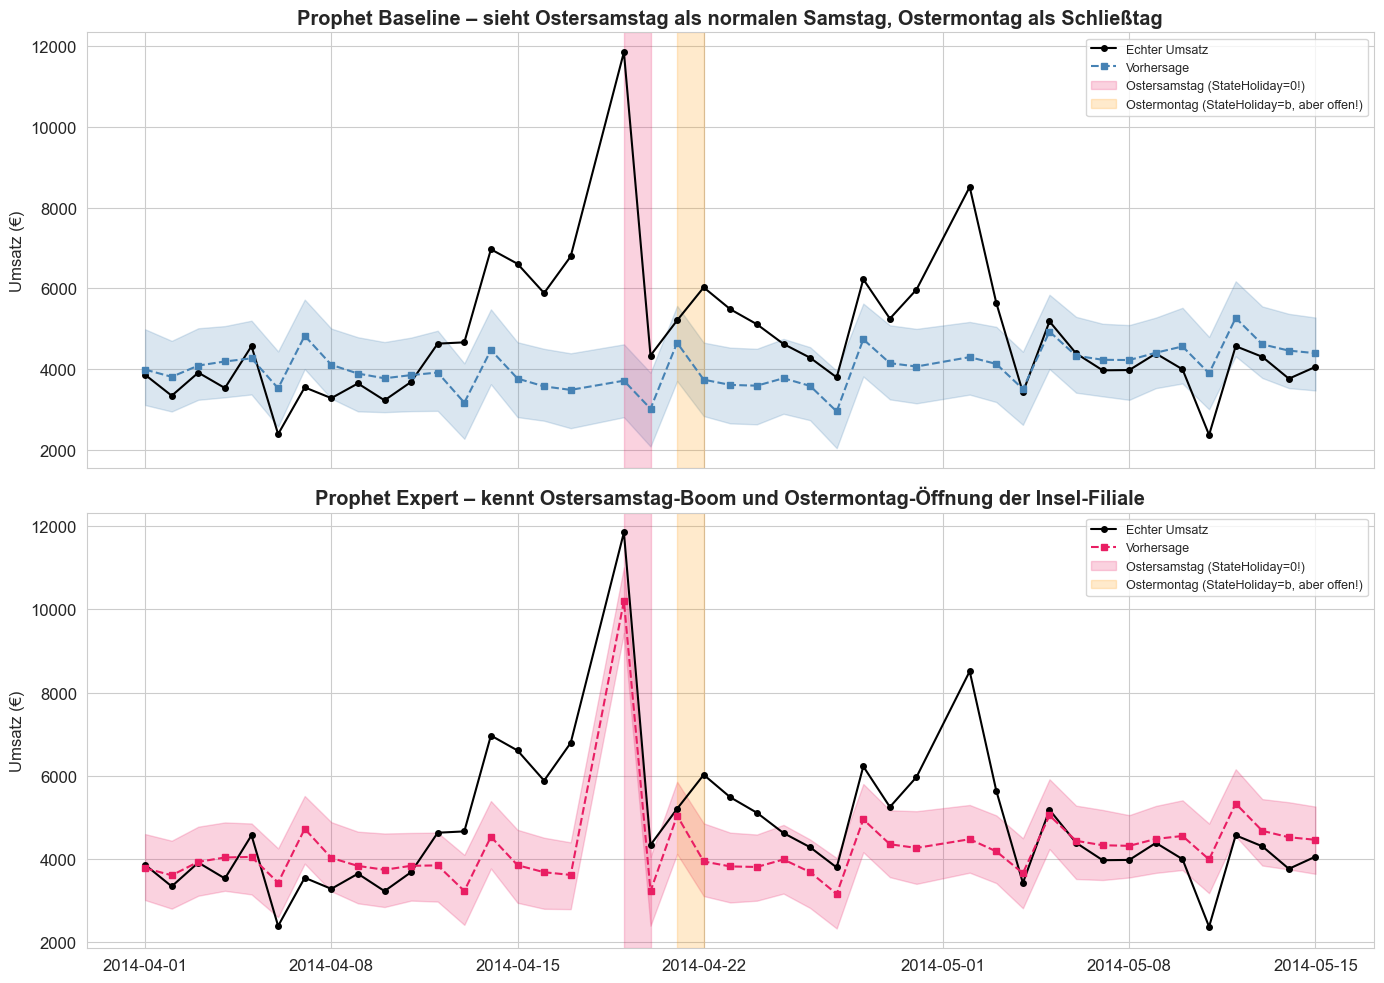

RMSPE Baseline: 28.2%
RMSPE Expert:   24.9%
Verbesserung:   3.3 Prozentpunkte


In [8]:
# Vergleichsplot Baseline vs. Expert – Filiale 530
y_true_530    = prophet_test_530['y'].values
test_dates_530 = prophet_test_530['ds'].values

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, fc, title, color in zip(
    axes,
    [fc_base_530, fc_expert_530],
    ['Prophet Baseline – sieht Ostersamstag als normalen Samstag, Ostermontag als Schließtag',
     'Prophet Expert – kennt Ostersamstag-Boom und Ostermontag-Öffnung der Insel-Filiale'],
    ['steelblue', '#E91E63']
):
    ax.plot(test_dates_530, y_true_530, 'o-', color='black', markersize=4,
            label='Echter Umsatz', linewidth=1.5)
    ax.plot(fc['ds'], fc['yhat'], 's--', color=color, markersize=4,
            label='Vorhersage', linewidth=1.5)
    ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'], alpha=0.2, color=color)
    ax.axvspan(pd.Timestamp('2014-04-19'), pd.Timestamp('2014-04-20'),
               alpha=0.2, color='#E91E63', label='Ostersamstag (StateHoliday=0!)')
    ax.axvspan(pd.Timestamp('2014-04-21'), pd.Timestamp('2014-04-22'),
               alpha=0.2, color='#FF9800', label='Ostermontag (StateHoliday=b, aber offen!)')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Umsatz (€)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# RMSPE direkt unter dem Plot
rmspe_base_530   = rmspe(y_true_530, fc_base_530['yhat'].values)
rmspe_expert_530 = rmspe(y_true_530, fc_expert_530['yhat'].values)
print(f'RMSPE Baseline: {rmspe_base_530:.1f}%')
print(f'RMSPE Expert:   {rmspe_expert_530:.1f}%')
print(f'Verbesserung:   {rmspe_base_530 - rmspe_expert_530:.1f} Prozentpunkte')

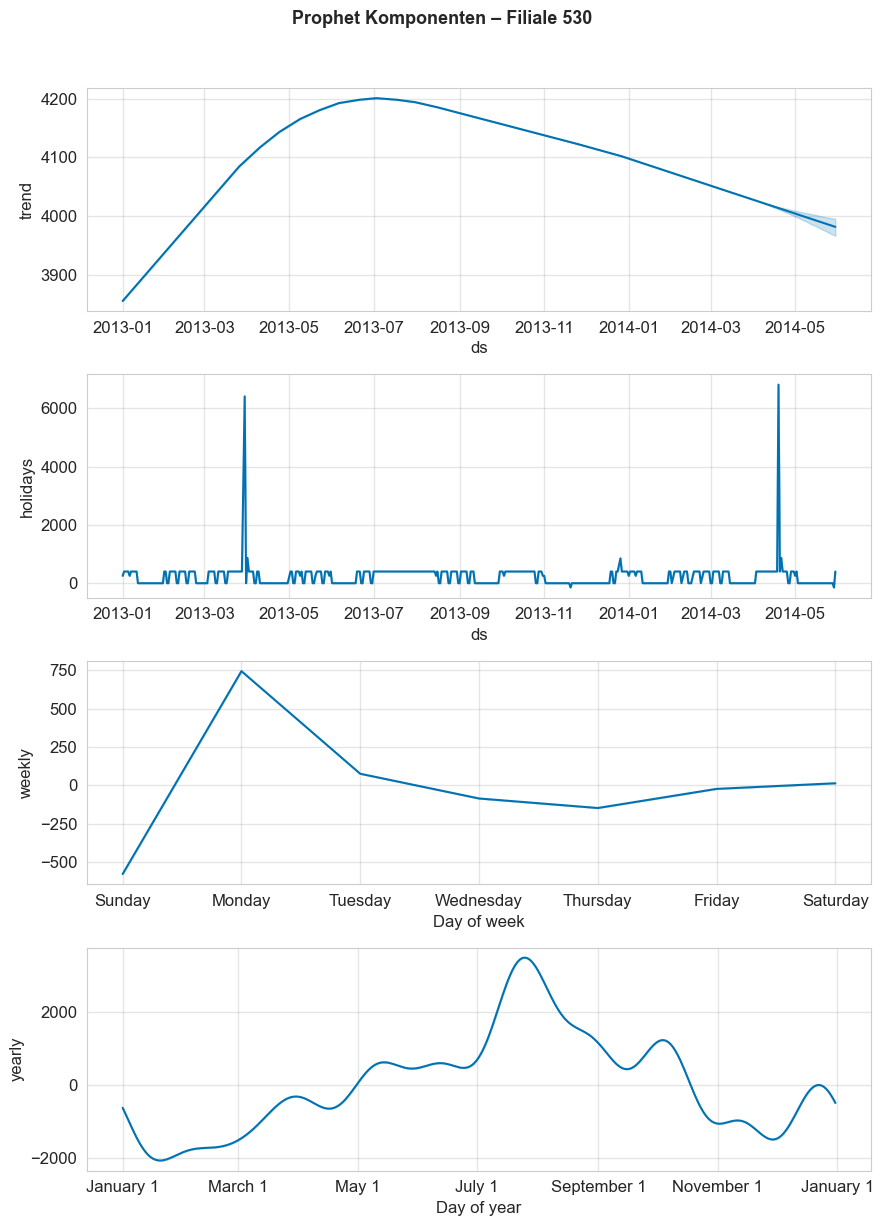

💡 Im holidays-Plot: ostersamstag zeigt positiven Effekt, ostermontag_insel ebenfalls!


In [9]:
# Komponenten-Plot – was hat Prophet gelernt?
future_530 = m_expert_530.make_future_dataframe(periods=60)
fc_full_530 = m_expert_530.predict(future_530)
fig = m_expert_530.plot_components(fc_full_530)
fig.suptitle(f'Prophet Komponenten – Filiale {STORE_530}', fontweight='bold', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()
print('💡 Im holidays-Plot: ostersamstag zeigt positiven Effekt, ostermontag_insel ebenfalls!')

---
## 🪜 3b. Schrittweise Verbesserung: Vom Datensatz zum Analyst-Wissen

Bisher haben wir Baseline und Expert direkt verglichen. Jetzt zeigen wir **wie** sich die Prognose Schritt für Schritt verbessert – jeder Analyst-Eingriff einzeln sichtbar gemacht.

| Stufe | Was kommt dazu | Idee |
|---|---|---|
| **0 – Baseline** | nur Standard-Feiertage (StateHoliday) | Was der Datensatz hergibt |
| **1 – Einzeltage** | + Ostersamstag, Ostermontag-Insel, Karfreitag, Tag-nach-1.Mai | Unsichtbare Tage explizit benennen |
| **2 – lower_window** | + Karwochen-Vorlauf (`lower_window=-5`) | Effekt über mehrere Tage strecken |

Die Karwoche zeigt in beiden Jahren erhöhten Umsatz (2013: 1.29x, 2014: 1.46x über Normal) – die Leute decken sich vor dem langen Osterwochenende ein. Mit `lower_window` lernt Prophet diesen Vorlauf, nicht nur den Samstags-Peak.

In [10]:
# Tag nach dem 1. Mai – Nachhol-/Brückentag-Effekt (Filiale 530 ist am 1. Mai geschlossen)
#   2013: 02.05. = Do, 6.275€ | 2014: 02.05. = Fr (Brückentag!), 8.513€
tag_nach_mai = pd.DataFrame({
    'ds': pd.to_datetime(['2013-05-02', '2014-05-02']),
    'holiday': 'tag_nach_1mai'
})

# === STUFE 1: Alle Sondertage als EINZELNE Tage (lower_window=0) ===
ostersamstag_einzeln = pd.DataFrame({
    'ds': pd.to_datetime(['2013-03-30', '2014-04-19']),
    'holiday': 'ostersamstag'
})
holidays_stufe1 = pd.concat([
    feiertage_a, karfreitag, ostersamstag_einzeln, ostermontag_insel,
    tag_nach_mai, weihnachten, schulferien
], ignore_index=True)

# === STUFE 2: Ostersamstag mit lower_window=-5 (ganze Karwoche) ===
ostersamstag_fenster = pd.DataFrame({
    'ds': pd.to_datetime(['2013-03-30', '2014-04-19']),
    'holiday': 'ostersamstag',
    'lower_window': -5,   # Mo–Fr der Karwoche
    'upper_window': 0
})
holidays_stufe2 = pd.concat([
    feiertage_a, karfreitag, ostersamstag_fenster, ostermontag_insel,
    tag_nach_mai, weihnachten, schulferien
], ignore_index=True)

print('Stufe 0 (Baseline):', holidays_baseline['holiday'].nunique(), 'Holiday-Typen')
print('Stufe 1 (Einzeltage):', holidays_stufe1['holiday'].nunique(), 'Holiday-Typen')
print('Stufe 2 (+lower_window): identische Typen, aber Ostersamstag deckt -5 Tage ab')

Stufe 0 (Baseline): 4 Holiday-Typen
Stufe 1 (Einzeltage): 7 Holiday-Typen
Stufe 2 (+lower_window): identische Typen, aber Ostersamstag deckt -5 Tage ab


In [11]:
# Drei Modelle trainieren
def fit_predict(holidays):
    m = Prophet(holidays=holidays, yearly_seasonality=True,
                weekly_seasonality=True, interval_width=0.80)
    m.fit(prophet_train_530)
    return m.predict(prophet_test_530[['ds']])

print('Trainiere 3 Stufen...')
fc_stufe0 = fit_predict(holidays_baseline)   # = Baseline von oben
fc_stufe1 = fit_predict(holidays_stufe1)
fc_stufe2 = fit_predict(holidays_stufe2)
print('✅ Alle 3 Stufen fertig!')

12:43:24 - cmdstanpy - INFO - Chain [1] start processing
12:43:24 - cmdstanpy - INFO - Chain [1] done processing


Trainiere 3 Stufen...


12:43:25 - cmdstanpy - INFO - Chain [1] start processing
12:43:25 - cmdstanpy - INFO - Chain [1] done processing
12:43:25 - cmdstanpy - INFO - Chain [1] start processing
12:43:25 - cmdstanpy - INFO - Chain [1] done processing


✅ Alle 3 Stufen fertig!


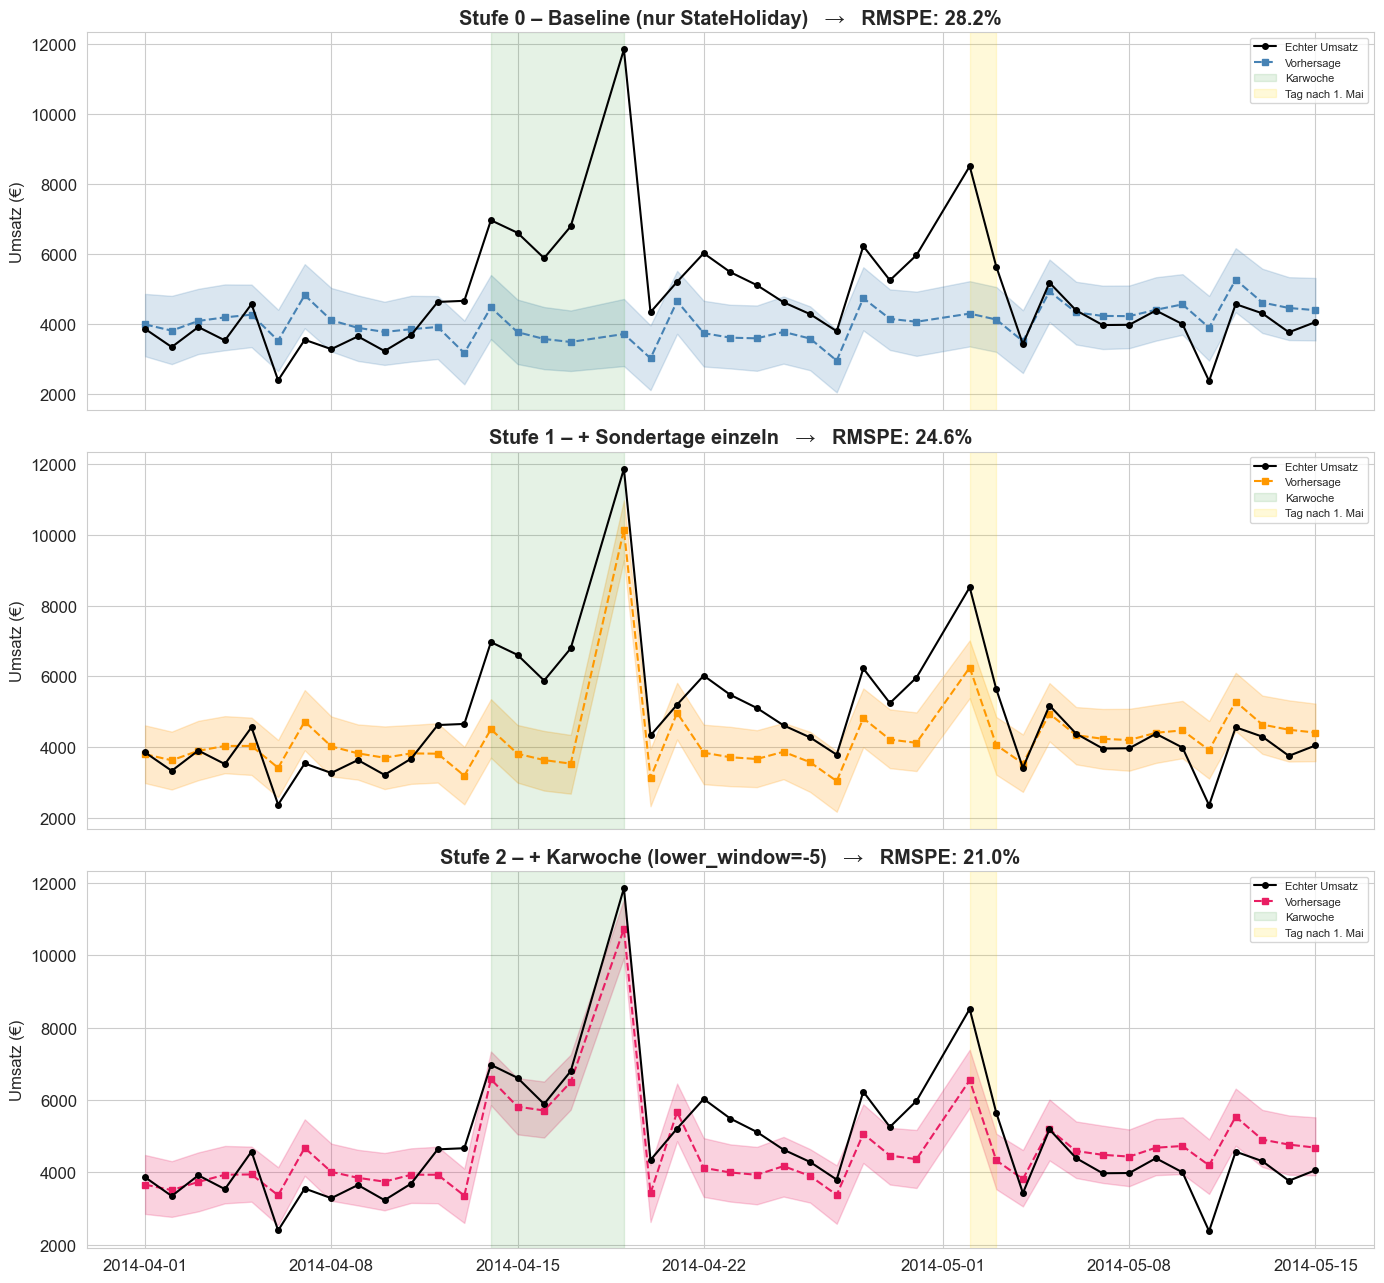

Schrittweise Verbesserung Filiale 530:
  Stufe 0 – Baseline (nur StateHoliday)         RMSPE: 28.2%
  Stufe 1 – + Sondertage einzeln                RMSPE: 24.6%
  Stufe 2 – + Karwoche (lower_window=-5)        RMSPE: 21.0%

🪜 Jeder Analyst-Schritt senkt den Fehler – das ist Analyst-in-the-Loop in Aktion!


In [12]:
# 3 Subplots untereinander + RMSPE je Stufe
stufen = [
    (fc_stufe0, 'Stufe 0 – Baseline (nur StateHoliday)', 'steelblue'),
    (fc_stufe1, 'Stufe 1 – + Sondertage einzeln', '#FF9800'),
    (fc_stufe2, 'Stufe 2 – + Karwoche (lower_window=-5)', '#E91E63'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

for ax, (fc, title, color) in zip(axes, stufen):
    ax.plot(test_dates_530, y_true_530, 'o-', color='black', markersize=4,
            label='Echter Umsatz', linewidth=1.5, zorder=5)
    ax.plot(fc['ds'], fc['yhat'], 's--', color=color, markersize=4,
            label='Vorhersage', linewidth=1.5)
    ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'], alpha=0.2, color=color)
    # Karwoche + Ostersamstag markieren
    ax.axvspan(pd.Timestamp('2014-04-14'), pd.Timestamp('2014-04-19'),
               alpha=0.1, color='green', label='Karwoche')
    ax.axvspan(pd.Timestamp('2014-05-02'), pd.Timestamp('2014-05-03'),
               alpha=0.15, color='gold', label='Tag nach 1. Mai')
    rmspe_val = rmspe(y_true_530, fc['yhat'].values)
    ax.set_title(f'{title}   →   RMSPE: {rmspe_val:.1f}%', fontweight='bold')
    ax.set_ylabel('Umsatz (€)')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

print('Schrittweise Verbesserung Filiale 530:')
for fc, title, _ in stufen:
    print(f'  {title:45s} RMSPE: {rmspe(y_true_530, fc["yhat"].values):.1f}%')
print()
print('🪜 Jeder Analyst-Schritt senkt den Fehler – das ist Analyst-in-the-Loop in Aktion!')

---
## 🌸 4. Fall 2: 1. Mai – Ferienort-Filiale vs. Stadtfiliale

### Das Problem

Der 1. Mai (Tag der Arbeit) ist bundesweit `StateHoliday='a'` – Prophet lernt daraus: **Umsatzeinbruch**.
Aber **20 von 1.115 Filialen** haben geöffnet und machen Rekord-Umsatz:

| Filiale | 1. Mai Ø | Normal Ø | Effekt |
|---|---|---|---|
| **262** (Ferienort) | **33.982€** | ~7.000€ | **+385%** |
| **16** (Stadtfiliale) | 0€ | ~7.681€ | −100% |

**Derselbe Feiertag, komplett entgegengesetzte Auswirkung** – das ist das stärkste Argument für Analyst-in-the-Loop!

In [13]:
# Splits für Filiale 262 und 16
# Testfenster: rund um den 1. Mai 2014
CUTOFF_MAI   = '2014-04-15'
TEST_END_MAI = '2014-05-31'

for store_id, label in [(262, 'Ferienort (offen am 1. Mai)'), (16, 'Stadtfiliale (geschlossen am 1. Mai)')]:
    df_s = train[train['Store'] == store_id].copy().sort_values('Date')
    df_tr = df_s[(df_s['Date'] < CUTOFF_MAI) & (df_s['Open'] == 1)]
    df_te = df_s[(df_s['Date'] >= CUTOFF_MAI) & (df_s['Date'] <= TEST_END_MAI) & (df_s['Open'] == 1)]
    mai = df_s[df_s['Date'].isin(pd.to_datetime(['2013-05-01', '2014-05-01']))]
    print(f'Filiale {store_id} – {label}')
    print(f'  Training: {len(df_tr)} Tage | Test: {len(df_te)} Tage')
    print(f'  1. Mai Umsatz: {mai["Sales"].values}')
    print()

Filiale 262 – Ferienort (offen am 1. Mai)
  Training: 469 Tage | Test: 47 Tage
  1. Mai Umsatz: [33151 34814]

Filiale 16 – Stadtfiliale (geschlossen am 1. Mai)
  Training: 389 Tage | Test: 37 Tage
  1. Mai Umsatz: [0 0]



In [14]:
def run_mai_experiment(store_id, label):
    df_s  = train[train['Store'] == store_id].copy().sort_values('Date')
    df_tr = df_s[(df_s['Date'] < CUTOFF_MAI) & (df_s['Open'] == 1)]
    df_te = df_s[(df_s['Date'] >= CUTOFF_MAI) & (df_s['Date'] <= TEST_END_MAI) & (df_s['Open'] == 1)]

    p_train = df_tr[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
    p_test  = df_te[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

    # Baseline: 1. Mai als normaler gesetzlicher Feiertag (Einbruch erwartet)
    m_base = Prophet(holidays=holidays_baseline, yearly_seasonality=True,
                     weekly_seasonality=True, interval_width=0.80)
    m_base.fit(p_train)
    fc_base = m_base.predict(p_test[['ds']])

    # Expert: 1. Mai als eigener Holiday – Prophet lernt den echten Effekt dieser Filiale
    maifeiertag = pd.DataFrame({
        'ds': pd.to_datetime(['2013-05-01', '2014-05-01']),
        'holiday': 'maifeiertag_filiale'
    })
    # 1. Mai aus allgemeinen Feiertagen herausnehmen damit kein Widerspruch entsteht
    feiertage_a_ohne_mai = feiertage_a[
        ~((feiertage_a['ds'].dt.month == 5) & (feiertage_a['ds'].dt.day == 1))
    ].copy()
    holidays_mai = pd.concat([
        feiertage_a_ohne_mai, ostern_standard, weihnachten, schulferien, maifeiertag
    ], ignore_index=True)

    m_expert = Prophet(holidays=holidays_mai, yearly_seasonality=True,
                       weekly_seasonality=True, interval_width=0.80)
    m_expert.fit(p_train)
    fc_expert = m_expert.predict(p_test[['ds']])

    return p_test, fc_base, fc_expert, df_te

print('Trainiere Modelle für Filiale 262 und 16...')
p_test_262, fc_base_262, fc_expert_262, df_te_262 = run_mai_experiment(262, 'Ferienort')
p_test_16,  fc_base_16,  fc_expert_16,  df_te_16  = run_mai_experiment(16, 'Stadtfiliale')
print('✅ Fertig!')

12:43:36 - cmdstanpy - INFO - Chain [1] start processing
12:43:36 - cmdstanpy - INFO - Chain [1] done processing


Trainiere Modelle für Filiale 262 und 16...


12:43:36 - cmdstanpy - INFO - Chain [1] start processing
12:43:36 - cmdstanpy - INFO - Chain [1] done processing
12:43:37 - cmdstanpy - INFO - Chain [1] start processing
12:43:37 - cmdstanpy - INFO - Chain [1] done processing
12:43:37 - cmdstanpy - INFO - Chain [1] start processing
12:43:37 - cmdstanpy - INFO - Chain [1] done processing


✅ Fertig!


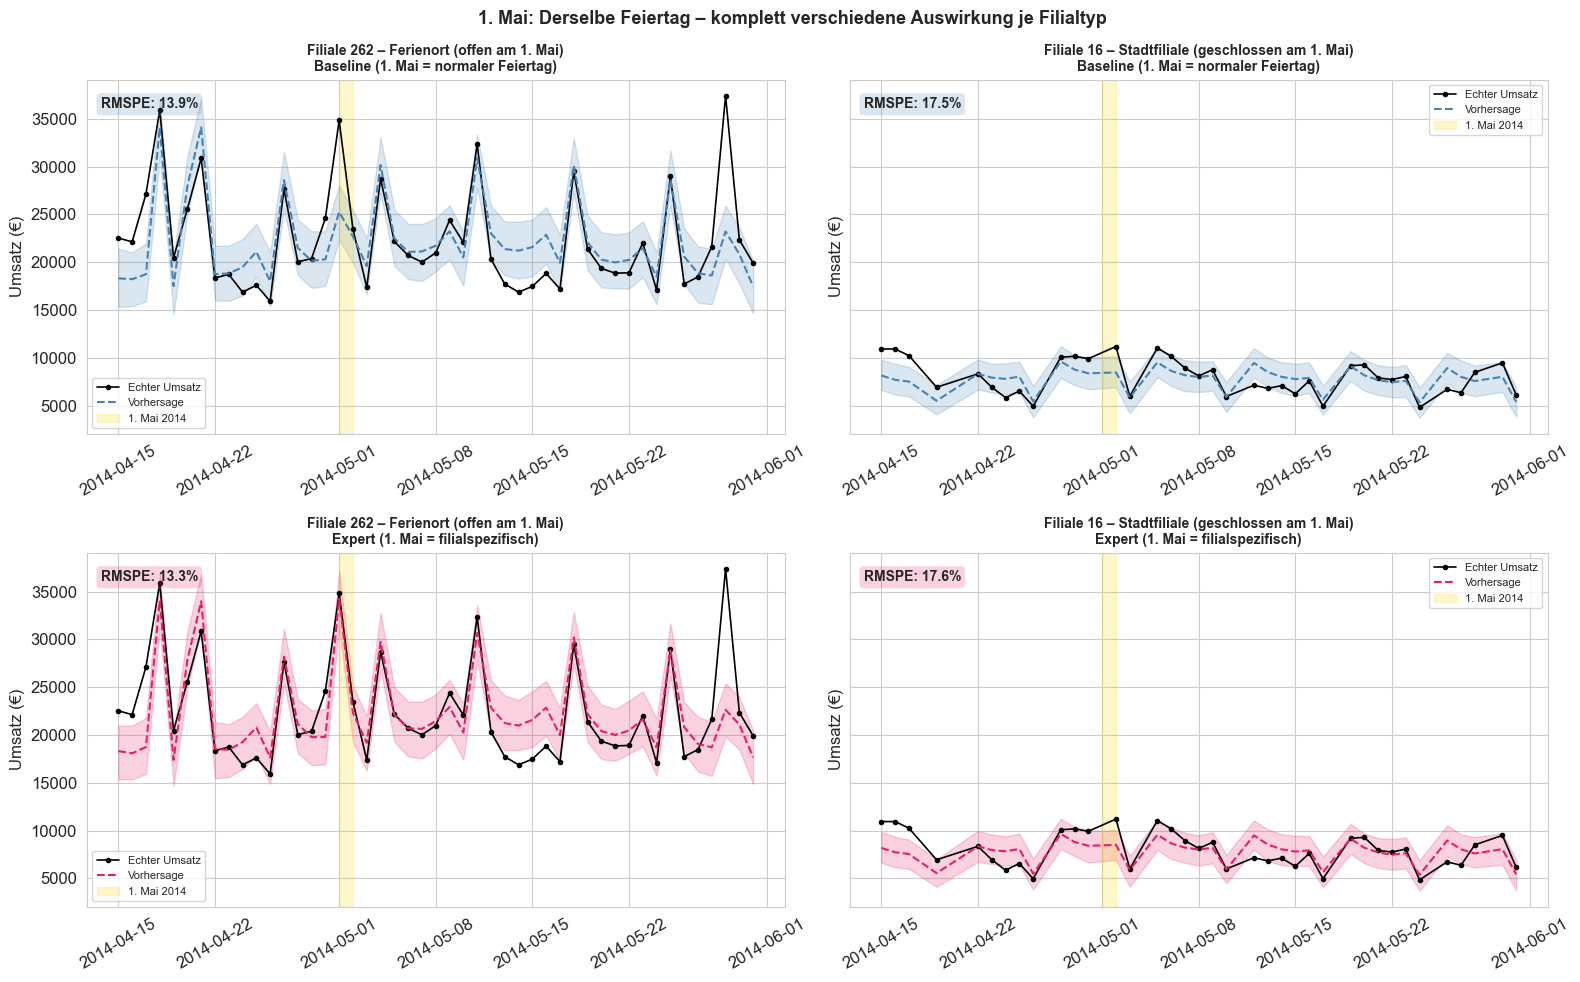

🎯 Key Message:
   Filiale 262 (Ferienort): Expert lernt aus 2013 → Umsatz-Boom am 1. Mai
   Filiale 16  (Stadt):     Expert lernt aus 2013 → Schließung am 1. Mai
   Derselbe Holiday-Name, aber filialspezifischer Effekt – kein generisches Modell kann das!


In [15]:
# Vergleichsplot: Filiale 262 (Ferienort) vs. Filiale 16 (Stadt)
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey='row')

for col, (p_test, fc_base, fc_expert, store_id, store_label) in enumerate([
    (p_test_262, fc_base_262, fc_expert_262, 262, 'Filiale 262 – Ferienort (offen am 1. Mai)'),
    (p_test_16,  fc_base_16,  fc_expert_16,  16,  'Filiale 16 – Stadtfiliale (geschlossen am 1. Mai)'),
]):
    y_true = p_test['y'].values
    dates  = p_test['ds'].values

    for row, (fc, model_label, color) in enumerate([
        (fc_base,   'Baseline (1. Mai = normaler Feiertag)', 'steelblue'),
        (fc_expert, 'Expert (1. Mai = filialspezifisch)',    '#E91E63'),
    ]):
        ax = axes[row][col]
        ax.plot(dates, y_true, 'o-', color='black', markersize=3, label='Echter Umsatz', linewidth=1.2)
        ax.plot(fc['ds'], fc['yhat'], '--', color=color, linewidth=1.5, label='Vorhersage')
        ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'], alpha=0.2, color=color)
        ax.axvspan(pd.Timestamp('2014-05-01'), pd.Timestamp('2014-05-02'),
                   alpha=0.2, color='gold', label='1. Mai 2014')
        ax.set_title(f'{store_label}\n{model_label}', fontweight='bold', fontsize=10)
        ax.set_ylabel('Umsatz (€)')
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=30)

        rmspe_val = rmspe(y_true, fc['yhat'].values)
        ax.text(0.02, 0.95, f'RMSPE: {rmspe_val:.1f}%', transform=ax.transAxes,
                fontweight='bold', fontsize=10, va='top',
                bbox=dict(boxstyle='round', facecolor=color, alpha=0.2))

plt.suptitle('1. Mai: Derselbe Feiertag – komplett verschiedene Auswirkung je Filialtyp',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('🎯 Key Message:')
print('   Filiale 262 (Ferienort): Expert lernt aus 2013 → Umsatz-Boom am 1. Mai')
print('   Filiale 16  (Stadt):     Expert lernt aus 2013 → Schließung am 1. Mai')
print('   Derselbe Holiday-Name, aber filialspezifischer Effekt – kein generisches Modell kann das!')

---
## 🏝️ 4b. Vertiefung: Filiale 262 ignoriert ALLE Frühjahrs-Feiertage

Der 1. Mai war kein Einzelfall. Schaut man sich Mai/Juni 2014 bei Filiale 262 genauer an, zeigt sich ein **systematisches Muster**: An jedem gesetzlichen Feiertag macht die Insel-Filiale Spitzenumsätze statt zu schließen.

| Datum 2014 | Feiertag | StateHoliday | Umsatz | Normal Ø ~20.000€ |
|---|---|---|---|---|
| 1. Mai | Tag der Arbeit | `a` | ~34.000€ | **+70%** |
| 29. Mai | Christi Himmelfahrt | `a` | **37.403€** | **+85%** |
| 30. Mai | Brückentag | `0` ❗ | 22.340€ | +12% |
| 9. Juni | Pfingstmontag | `a` | 34.692€ | **+72%** |
| Sonntage | (geöffnet!) | `0` | ~30.000€ | **+50%** |

Während eine normale Filiale an diesen Tagen geschlossen ist (`StateHoliday='a'` → Einbruch), dreht Filiale 262 voll auf – Touristen haben am Feiertag Zeit zum Einkaufen. Wir bauen jetzt **alle** diese Insel-Feiertage als positiven Effekt ein.

In [16]:
# Testfenster bis Mitte Juni erweitern, damit Himmelfahrt + Pfingsten enthalten sind
STORE_262 = 262
CUTOFF_262   = '2014-04-15'
TEST_END_262 = '2014-06-15'

df_262 = train[train['Store'] == STORE_262].copy().sort_values('Date').reset_index(drop=True)
df_train_262 = df_262[(df_262['Date'] < CUTOFF_262) & (df_262['Open'] == 1)]
df_test_262b = df_262[(df_262['Date'] >= CUTOFF_262) & (df_262['Date'] <= TEST_END_262) & (df_262['Open'] == 1)]

p_train_262 = df_train_262[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
p_test_262b = df_test_262b[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

print(f'Filiale {STORE_262}: Training {len(df_train_262)} Tage, Test {len(df_test_262b)} Tage')
print(f'Testfenster: {df_test_262b["Date"].min().date()} – {df_test_262b["Date"].max().date()}')

Filiale 262: Training 469 Tage, Test 62 Tage
Testfenster: 2014-04-15 – 2014-06-15


In [17]:
# 🎯 ANALYST-WISSEN: Alle Frühjahrs-Feiertage als Insel-Effekt (positiv!)
# Diese Tage sind im Datensatz als StateHoliday='a' (=Einbruch erwartet) kodiert,
# aber Filiale 262 macht hier ihre höchsten Umsätze.
feiertage_insel_262 = pd.DataFrame({
    'ds': pd.to_datetime([
        '2013-05-01', '2014-05-01',   # Tag der Arbeit
        '2013-05-09', '2014-05-29',   # Christi Himmelfahrt
        '2013-05-20', '2014-06-09',   # Pfingstmontag
    ]),
    'holiday': 'feiertag_insel'
})

# Brückentage (StateHoliday='0', aber erhöhter Umsatz)
brueckentage_262 = pd.DataFrame({
    'ds': pd.to_datetime(['2013-05-10', '2014-05-30']),  # Freitag nach Himmelfahrt
    'holiday': 'brueckentag'
})

# Baseline: alle gesetzlichen Feiertage als generischer Effekt (Einbruch)
holidays_262_baseline = pd.concat([feiertage_a, ostern_standard, weihnachten, schulferien],
                                  ignore_index=True)

# Expert: Frühjahrs-Feiertage aus generischem Set entfernen, als Insel-Effekt neu einbauen
insel_daten = feiertage_insel_262['ds'].tolist()
feiertage_a_ohne_insel = feiertage_a[~feiertage_a['ds'].isin(insel_daten)].copy()
holidays_262_expert = pd.concat([
    feiertage_a_ohne_insel, ostern_standard, weihnachten, schulferien,
    feiertage_insel_262, brueckentage_262
], ignore_index=True)

print('🎯 Expert-Modell für Filiale 262 kennt:')
print('   feiertag_insel → 1. Mai, Himmelfahrt, Pfingstmontag als POSITIVE Effekte')
print('   brueckentag    → Freitag nach Himmelfahrt (StateHoliday=0!)')

🎯 Expert-Modell für Filiale 262 kennt:
   feiertag_insel → 1. Mai, Himmelfahrt, Pfingstmontag als POSITIVE Effekte
   brueckentag    → Freitag nach Himmelfahrt (StateHoliday=0!)


In [18]:
# Baseline vs. Expert für Filiale 262
m_base_262 = Prophet(holidays=holidays_262_baseline, yearly_seasonality=True,
                     weekly_seasonality=True, interval_width=0.80)
m_base_262.fit(p_train_262)
fc_base_262b = m_base_262.predict(p_test_262b[['ds']])

m_expert_262 = Prophet(holidays=holidays_262_expert, yearly_seasonality=True,
                       weekly_seasonality=True, interval_width=0.80)
m_expert_262.fit(p_train_262)
fc_expert_262b = m_expert_262.predict(p_test_262b[['ds']])
print('✅ Beide Modelle trainiert!')

12:43:48 - cmdstanpy - INFO - Chain [1] start processing
12:43:48 - cmdstanpy - INFO - Chain [1] done processing
12:43:48 - cmdstanpy - INFO - Chain [1] start processing
12:43:48 - cmdstanpy - INFO - Chain [1] done processing


✅ Beide Modelle trainiert!


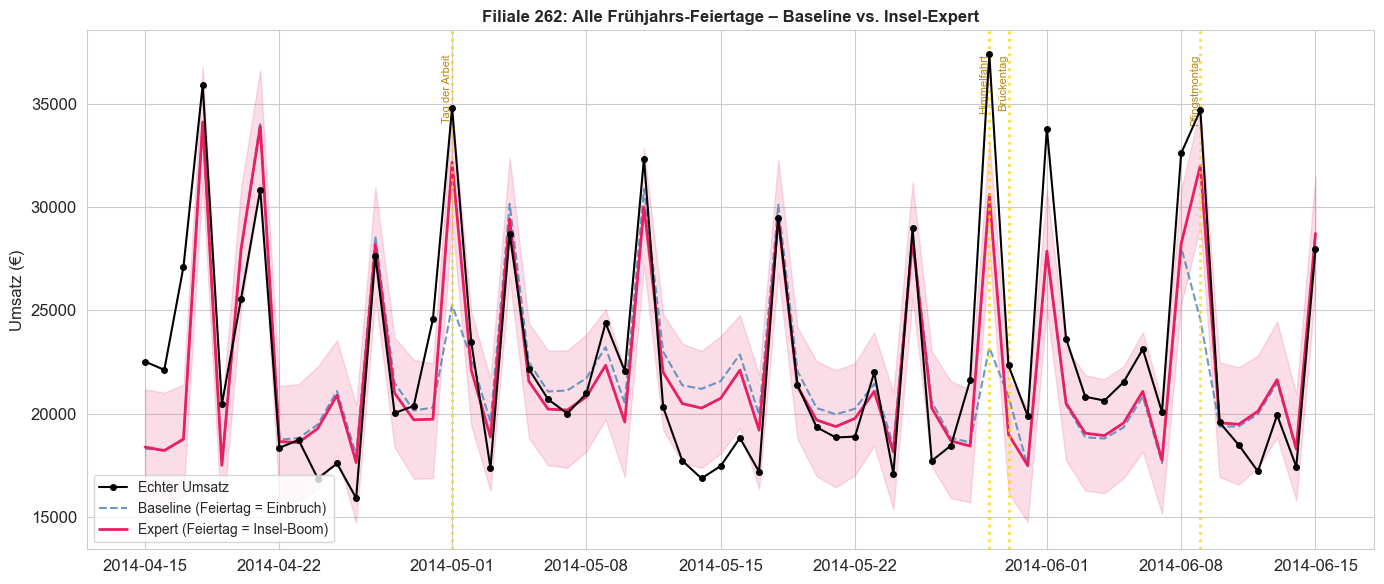

Modellvergleich Filiale 262 (Frühjahrs-Feiertage):
Baseline:
  RMSE:  3599 €
  RMSPE: 13.7%
Expert  :
  RMSE:  2654 €
  RMSPE: 11.2%

🏝️ Die Baseline bricht an jedem Feiertag ein – Expert kennt das Insel-Muster!


In [19]:
# Vergleichsplot mit allen Frühjahrs-Feiertagen markiert
y_true_262b    = p_test_262b['y'].values
test_dates_262b = p_test_262b['ds'].values

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates_262b, y_true_262b, 'o-', color='black', markersize=4,
        label='Echter Umsatz', linewidth=1.5, zorder=5)
ax.plot(fc_base_262b['ds'], fc_base_262b['yhat'], '--', color='steelblue',
        linewidth=1.5, label='Baseline (Feiertag = Einbruch)', alpha=0.8)
ax.plot(fc_expert_262b['ds'], fc_expert_262b['yhat'], '-', color='#E91E63',
        linewidth=2, label='Expert (Feiertag = Insel-Boom)')
ax.fill_between(fc_expert_262b['ds'], fc_expert_262b['yhat_lower'], fc_expert_262b['yhat_upper'],
                alpha=0.15, color='#E91E63')

# Alle Frühjahrs-Feiertage markieren
feiertage_marker = {
    '2014-05-01': 'Tag der Arbeit',
    '2014-05-29': 'Himmelfahrt',
    '2014-05-30': 'Brückentag',
    '2014-06-09': 'Pfingstmontag',
}
for datum, name in feiertage_marker.items():
    ax.axvline(pd.Timestamp(datum), color='gold', linestyle=':', linewidth=2, alpha=0.8)
    ax.text(pd.Timestamp(datum), ax.get_ylim()[1]*0.97, name, rotation=90,
            fontsize=8, va='top', ha='right', color='darkgoldenrod')

ax.set_title(f'Filiale {STORE_262}: Alle Frühjahrs-Feiertage – Baseline vs. Insel-Expert',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Umsatz (€)')
ax.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.show()

print('Modellvergleich Filiale 262 (Frühjahrs-Feiertage):')
print_metrics(y_true_262b, fc_base_262b['yhat'].values,   'Baseline')
print_metrics(y_true_262b, fc_expert_262b['yhat'].values, 'Expert  ')
print()
print('🏝️ Die Baseline bricht an jedem Feiertag ein – Expert kennt das Insel-Muster!')

---
## 🏷️ 5. Fall 3: Promo-Effekte – Holiday vs. Regressor

Bisher haben wir Domänenwissen nur über **Holidays** eingebaut. Für Promotionen gibt es einen besseren Weg: den **Regressor**.

### Holiday vs. Regressor – was ist der Unterschied?

| | Holiday | Regressor (`add_regressor`) |
|---|---|---|
| Wertebereich | nur 0/1 (Tag ist Event oder nicht) | beliebig (auch kontinuierlich) |
| Zukunft | aus Kalender ableitbar | **muss selbst geliefert werden** |
| Modus | additiv oder multiplikativ | additiv oder multiplikativ |
| Typischer Einsatz | Feiertage, Events | Promo, Preis, Wetter |

Bei Rossmann ist `Promo` bereits als 0/1-Spalte im Datensatz – auch für den Testzeitraum. Wir können sie also direkt als Regressor nutzen, ohne sie schätzen zu müssen.

### Filiale 198 – der Promo-Junkie

Filiale 198 reagiert extrem stark auf Promotionen: **+145% Umsatz** an Promo-Tagen. Ideal um den Effekt sichtbar zu machen.

Wir vergleichen drei Modelle:
1. **Baseline** – nur Feiertage, kein Promo-Wissen
2. **Promo als Holiday** – jeder Promo-Tag als Event
3. **Promo als Regressor** – `add_regressor('promo')`

Filiale 198:
  Training: 682 Tage (307 mit Promo)
  Test:     47 Tage (21 mit Promo)


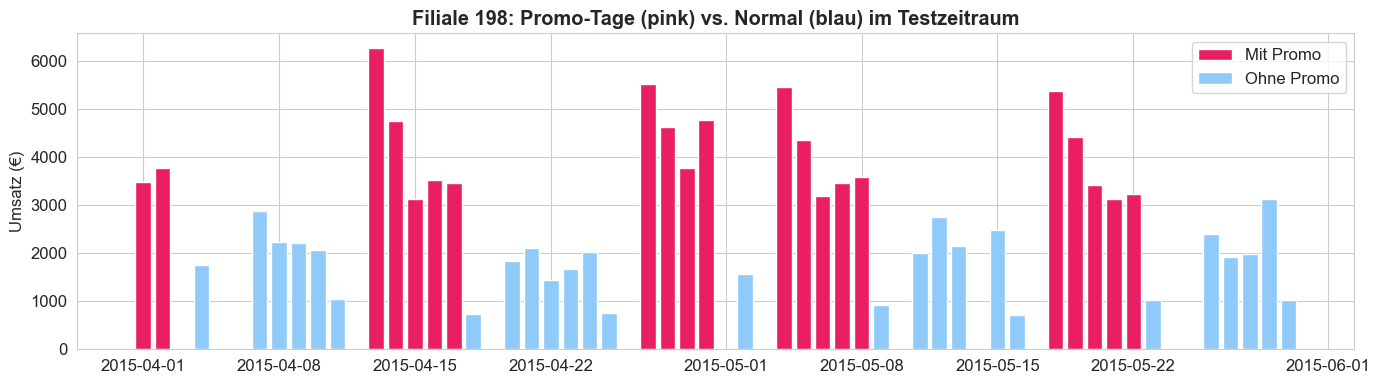

💡 Der Promo-Effekt ist riesig – an Promo-Tagen oft das Doppelte oder mehr!


In [20]:
STORE_PROMO    = 198
CUTOFF_PROMO   = '2015-04-01'
TEST_END_PROMO = '2015-05-31'

df_198 = train[train['Store'] == STORE_PROMO].copy().sort_values('Date').reset_index(drop=True)

df_train_198 = df_198[(df_198['Date'] < CUTOFF_PROMO) & (df_198['Open'] == 1)]
df_test_198  = df_198[(df_198['Date'] >= CUTOFF_PROMO) & (df_198['Date'] <= TEST_END_PROMO) & (df_198['Open'] == 1)]

print(f'Filiale {STORE_PROMO}:')
print(f'  Training: {len(df_train_198)} Tage ({(df_train_198["Promo"]==1).sum()} mit Promo)')
print(f'  Test:     {len(df_test_198)} Tage ({(df_test_198["Promo"]==1).sum()} mit Promo)')

# Promo-Muster im Test zeigen
fig, ax = plt.subplots(figsize=(14, 4))
promo_tage    = df_test_198[df_test_198['Promo'] == 1]
kein_promo    = df_test_198[df_test_198['Promo'] == 0]
ax.bar(promo_tage['Date'], promo_tage['Sales'], color='#E91E63', label='Mit Promo', width=0.8)
ax.bar(kein_promo['Date'], kein_promo['Sales'], color='#90CAF9', label='Ohne Promo', width=0.8)
ax.set_title(f'Filiale {STORE_PROMO}: Promo-Tage (pink) vs. Normal (blau) im Testzeitraum', fontweight='bold')
ax.set_ylabel('Umsatz (€)')
ax.legend()
plt.tight_layout()
plt.show()
print('💡 Der Promo-Effekt ist riesig – an Promo-Tagen oft das Doppelte oder mehr!')

In [21]:
# === Modell 1: Baseline (nur Feiertage) ===
p_train_198 = df_train_198[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
p_test_198  = df_test_198[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

m_base_198 = Prophet(holidays=holidays_baseline, yearly_seasonality=True,
                     weekly_seasonality=True, interval_width=0.80)
m_base_198.fit(p_train_198)
fc_base_198 = m_base_198.predict(p_test_198[['ds']])
print('✅ Modell 1 (Baseline) fertig')

12:44:01 - cmdstanpy - INFO - Chain [1] start processing
12:44:02 - cmdstanpy - INFO - Chain [1] done processing


✅ Modell 1 (Baseline) fertig


In [22]:
# === Modell 2: Promo als HOLIDAY ===
# Jeder Promo-Tag wird als Event behandelt
promo_holidays = df_198[df_198['Promo'] == 1][['Date']].rename(columns={'Date': 'ds'})
promo_holidays['holiday'] = 'promo'
holidays_mit_promo = pd.concat([holidays_baseline, promo_holidays], ignore_index=True)

m_holiday_198 = Prophet(holidays=holidays_mit_promo, yearly_seasonality=True,
                        weekly_seasonality=True, interval_width=0.80)
m_holiday_198.fit(p_train_198)
fc_holiday_198 = m_holiday_198.predict(p_test_198[['ds']])
print('✅ Modell 2 (Promo als Holiday) fertig')

12:44:03 - cmdstanpy - INFO - Chain [1] start processing
12:44:03 - cmdstanpy - INFO - Chain [1] done processing


✅ Modell 2 (Promo als Holiday) fertig


In [23]:
# === Modell 3: Promo als REGRESSOR ===
# Die 'promo'-Spalte muss in Training UND Test vorhanden sein
p_train_reg = df_train_198[['Date', 'Sales', 'Promo']].rename(
    columns={'Date': 'ds', 'Sales': 'y', 'Promo': 'promo'})
p_test_reg  = df_test_198[['Date', 'Promo']].rename(
    columns={'Date': 'ds', 'Promo': 'promo'})

m_reg_198 = Prophet(holidays=holidays_baseline, yearly_seasonality=True,
                    weekly_seasonality=True, interval_width=0.80)
# 🎯 Der entscheidende Schritt: Promo als Regressor anmelden
# mode='multiplicative', weil Promo den Umsatz prozentual anhebt (+145%!)
m_reg_198.add_regressor('promo', mode='multiplicative')
m_reg_198.fit(p_train_reg)
fc_reg_198 = m_reg_198.predict(p_test_reg)
print('✅ Modell 3 (Promo als Regressor) fertig')

12:44:05 - cmdstanpy - INFO - Chain [1] start processing
12:44:05 - cmdstanpy - INFO - Chain [1] done processing


✅ Modell 3 (Promo als Regressor) fertig


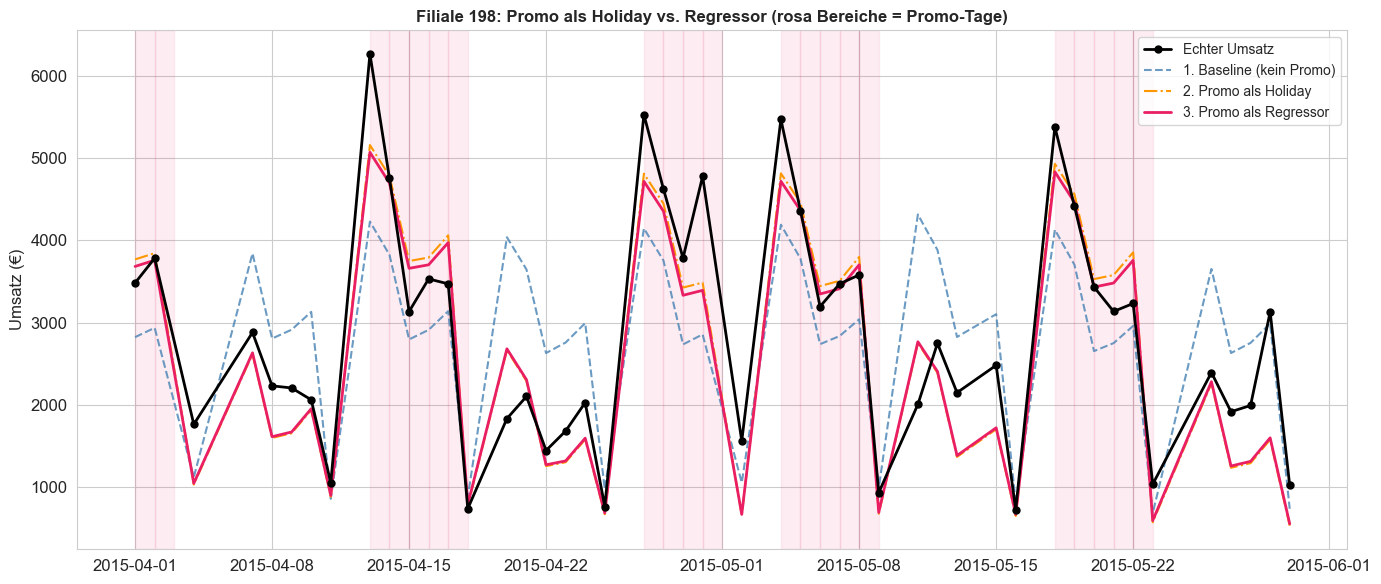

Modellvergleich Filiale 198:
1. Baseline       :
  RMSE:  977 €
  RMSPE: 40.2%
2. Promo=Holiday  :
  RMSE:  564 €
  RMSPE: 24.2%
3. Promo=Regressor:
  RMSE:  565 €
  RMSPE: 23.6%


In [24]:
# Vergleich aller drei Modelle
y_true_198    = p_test_198['y'].values
test_dates_198 = p_test_198['ds'].values

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates_198, y_true_198, 'o-', color='black', markersize=5,
        label='Echter Umsatz', linewidth=2, zorder=5)
ax.plot(fc_base_198['ds'], fc_base_198['yhat'], '--', color='steelblue',
        linewidth=1.5, label='1. Baseline (kein Promo)', alpha=0.8)
ax.plot(fc_holiday_198['ds'], fc_holiday_198['yhat'], '-.', color='#FF9800',
        linewidth=1.5, label='2. Promo als Holiday')
ax.plot(fc_reg_198['ds'], fc_reg_198['yhat'], '-', color='#E91E63',
        linewidth=2, label='3. Promo als Regressor')

# Promo-Tage im Hintergrund markieren
for d in df_test_198[df_test_198['Promo'] == 1]['Date']:
    ax.axvspan(d, d + pd.Timedelta(days=1), alpha=0.08, color='#E91E63')

ax.set_title(f'Filiale {STORE_PROMO}: Promo als Holiday vs. Regressor (rosa Bereiche = Promo-Tage)',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Umsatz (€)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Modellvergleich Filiale 198:')
print_metrics(y_true_198, fc_base_198['yhat'].values,    '1. Baseline       ')
print_metrics(y_true_198, fc_holiday_198['yhat'].values, '2. Promo=Holiday  ')
print_metrics(y_true_198, fc_reg_198['yhat'].values,     '3. Promo=Regressor')

### 💡 Warum Regressor oft besser ist als Holiday

Beide Ansätze können den Promo-Effekt abbilden, aber:

- **Holiday** behandelt jeden Promo-Tag als isoliertes Event. Bei sehr vielen Promo-Tagen wird das Modell unübersichtlich und überschätzt evtl. einzelne Tage.
- **Regressor** lernt **einen** Promo-Koeffizienten aus allen Daten und wendet ihn konsistent an. Das ist robuster, besser interpretierbar (\"Promo = +X%\") und der natürliche Weg für wiederkehrende, planbare Einflüsse.

Faustregel: **Einmalige Kalender-Events → Holiday. Wiederkehrende, steuerbare Einflüsse (Promo, Preis) → Regressor.**

---
## 📏 6. Gesamtvergleich & Fazit

### Was haben wir gelernt?

| Effekt | Im Datensatz | Prophet Baseline | Prophet Expert |
|---|---|---|---|
| Ostersamstag (530) | `StateHoliday=0` | ❌ normaler Samstag | ✅ Boom-Tag |
| Ostermontag (530) | `StateHoliday=b` | ❌ Schließung | ✅ geöffnet |
| 1. Mai Ferienort (262) | `StateHoliday=a` | ❌ Einbruch | ✅ Boom |
| Himmelfahrt/Pfingsten (262) | `StateHoliday=a` | ❌ Einbruch | ✅ Boom |
| Brückentag (262) | `StateHoliday=0` | ❌ normaler Tag | ✅ erhöht |
| 1. Mai Stadtfiliale (16) | `StateHoliday=a` | ✅ Einbruch | ✅ Einbruch |
| Promo (198) | `Promo=1` | ❌ ignoriert | ✅ als Regressor (+145%) |

### 🔑 Key Takeaways

1. **Derselbe Feiertag kann je nach Filialtyp einen komplett entgegengesetzten Effekt haben** – ein generisches Modell kann das nicht unterscheiden.
2. **Manche Effekte sind im Datensatz unsichtbar** (Ostersamstag = `StateHoliday=0`) – nur der Analyst erkennt sie.
3. **Holidays für Events, Regressoren für steuerbare Einflüsse** – Promo, Preis und Wetter gehören als `add_regressor` ins Modell, nicht als Holiday.
4. Der **Analyst-in-the-Loop** ist kein Nice-to-have – bei Insel-, Ferienort-Filialen und Promo-getriebenen Filialen ist er unverzichtbar.

### 🚀 Mögliche nächste Schritte
- Mehrere Regressoren kombinieren (Promo + Promo2 + CompetitionDistance)
- Cross-Validation mit Prophet (`cross_validation()`) für robustere Metriken
- Mehrere Filialen gleichzeitig mit hierarchischen Modellen vorhersagen

In [27]:
# Diagnose: Was hat der Regressor gelernt?
print("=== Regressor-Koeffizient ===")
from prophet.utilities import regressor_coefficients
print(regressor_coefficients(m_reg_198))

# Wie verteilt sich der Promo-Effekt im Training? Ist er konstant?
df_promo_check = df_train_198.copy()
print("\n=== Promo-Effekt nach Wochentag ===")
# Promo wirkt evtl. an verschiedenen Wochentagen unterschiedlich
promo_by_day = (
    df_promo_check.groupby(['DayOfWeek', 'Promo'])['Sales']
    .mean().unstack()
)
promo_by_day['boost_%'] = (promo_by_day[1] / promo_by_day[0] - 1) * 100
print(promo_by_day.round(0))

=== Regressor-Koeffizient ===
  regressor  regressor_mode  center  coef_lower      coef  coef_upper
0     promo  multiplicative     0.0    1.045886  1.045886    1.045886

=== Promo-Effekt nach Wochentag ===
Promo           0       1  boost_%
DayOfWeek                         
1          2043.0  5841.0    186.0
2          2261.0  5041.0    123.0
3          1821.0  3506.0     93.0
4          2007.0  3483.0     74.0
5          2421.0  3634.0     50.0
6           933.0     NaN      NaN


12:44:24 - cmdstanpy - INFO - Chain [1] start processing
12:44:24 - cmdstanpy - INFO - Chain [1] done processing
12:44:25 - cmdstanpy - INFO - Chain [1] start processing
12:44:25 - cmdstanpy - INFO - Chain [1] done processing


Gelernte Koeffizienten Modell B (Promo × Wochentag):
  regressor   coef
promo_frueh 3335.0
promo_spaet 1475.0

RMSPE-Vergleich:
  Original (multiplicative, default):  23.6%
  Modell A (additive, prior_scale=10): 24.4%
  Modell B (Promo × Wochentag):        22.9%


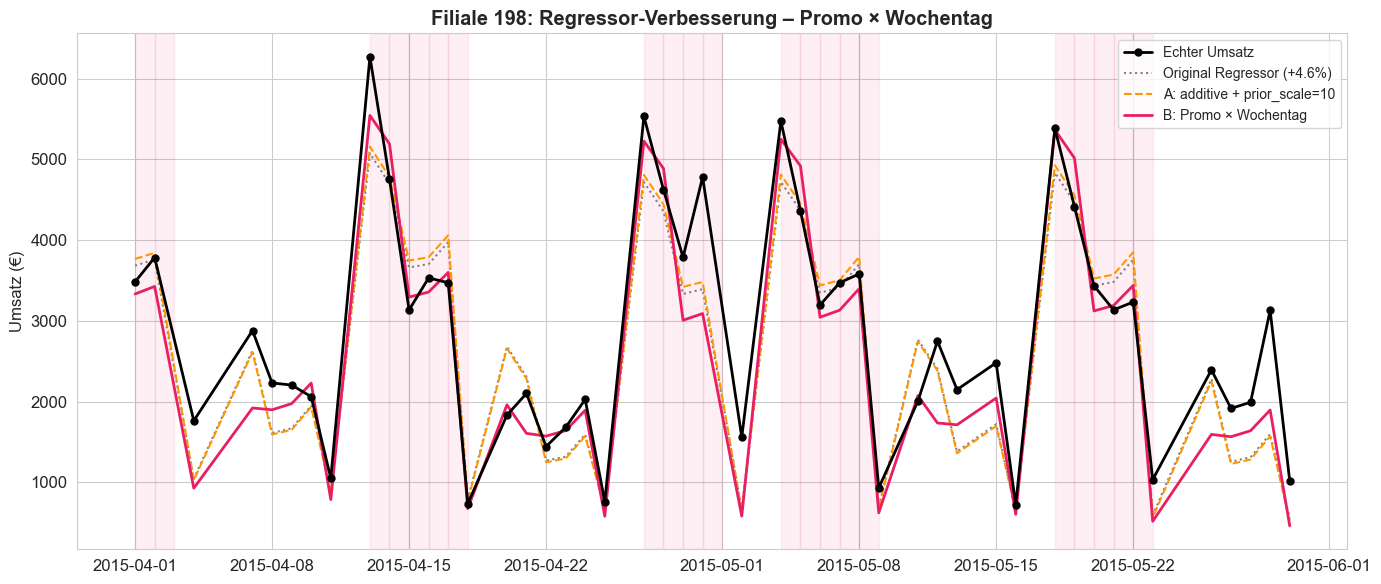


💡 Kernaussage: Ein Regressor ist nur so gut wie seine Annahme.
   Ein konstanter Promo-Effekt scheitert, weil der echte Effekt von 186% (Mo) auf 50% (Fr) fällt.
   Erst die Interaktion mit dem Wochentag bildet das korrekt ab.


In [28]:
# === VERBESSERUNG DES PROMO-REGRESSORS ===
# Problem: Der einfache Regressor lernte nur +4.6% (coef=1.046),
# obwohl der echte Promo-Boost +50% bis +186% beträgt – je nach Wochentag.

# Trainings- und Testdaten mit Wochentag-Information vorbereiten
def build_promo_features(df):
    out = df[['Date', 'Promo']].rename(columns={'Date': 'ds', 'Promo': 'promo'}).copy()
    wochentag = out['ds'].dt.dayofweek            # 0=Mo, 1=Di, ... 5=Sa
    # Promo getrennt nach früh (Mo/Di, starker Effekt) und spät (Mi–Fr, schwächer)
    out['promo_frueh'] = out['promo'] * wochentag.isin([0, 1]).astype(int)
    out['promo_spaet'] = out['promo'] * (~wochentag.isin([0, 1])).astype(int)
    return out

train_feat = build_promo_features(df_train_198)
train_feat['y'] = df_train_198['Sales'].values
test_feat  = build_promo_features(df_test_198)

# --- Modell A: einfacher Regressor mit höherem prior_scale ---
mA = Prophet(holidays=holidays_baseline, yearly_seasonality=True,
             weekly_seasonality=True, interval_width=0.80)
mA.add_regressor('promo', mode='additive', prior_scale=10)
mA.fit(train_feat[['ds', 'y', 'promo']])
fcA = mA.predict(test_feat[['ds', 'promo']])

# --- Modell B: Promo × Wochentag-Interaktion (zwei Regressoren) ---
mB = Prophet(holidays=holidays_baseline, yearly_seasonality=True,
             weekly_seasonality=True, interval_width=0.80)
mB.add_regressor('promo_frueh', mode='additive', prior_scale=10)
mB.add_regressor('promo_spaet', mode='additive', prior_scale=10)
mB.fit(train_feat[['ds', 'y', 'promo_frueh', 'promo_spaet']])
fcB = mB.predict(test_feat[['ds', 'promo_frueh', 'promo_spaet']])

# === Vergleich ===
from prophet.utilities import regressor_coefficients
print("Gelernte Koeffizienten Modell B (Promo × Wochentag):")
print(regressor_coefficients(mB)[['regressor', 'coef']].round(0).to_string(index=False))
print()

y_true = df_test_198['Sales'].values
print("RMSPE-Vergleich:")
print(f"  Original (multiplicative, default):  {rmspe(y_true, fc_reg_198['yhat'].values):.1f}%")
print(f"  Modell A (additive, prior_scale=10): {rmspe(y_true, fcA['yhat'].values):.1f}%")
print(f"  Modell B (Promo × Wochentag):        {rmspe(y_true, fcB['yhat'].values):.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_test_198['Date'], y_true, 'o-', color='black', markersize=5,
        label='Echter Umsatz', linewidth=2, zorder=5)
ax.plot(fc_reg_198['ds'], fc_reg_198['yhat'], ':', color='gray',
        linewidth=1.5, label='Original Regressor (+4.6%)')
ax.plot(fcA['ds'], fcA['yhat'], '--', color='#FF9800',
        linewidth=1.5, label='A: additive + prior_scale=10')
ax.plot(fcB['ds'], fcB['yhat'], '-', color='#E91E63',
        linewidth=2, label='B: Promo × Wochentag')
for d in df_test_198[df_test_198['Promo'] == 1]['Date']:
    ax.axvspan(d, d + pd.Timedelta(days=1), alpha=0.07, color='#E91E63')
ax.set_title(f'Filiale {STORE_PROMO}: Regressor-Verbesserung – Promo × Wochentag', fontweight='bold')
ax.set_ylabel('Umsatz (€)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print()
print('💡 Kernaussage: Ein Regressor ist nur so gut wie seine Annahme.')
print('   Ein konstanter Promo-Effekt scheitert, weil der echte Effekt von 186% (Mo) auf 50% (Fr) fällt.')
print('   Erst die Interaktion mit dem Wochentag bildet das korrekt ab.')

In [29]:
# Wo sitzt der verbleibende Fehler? Residuen je Tag analysieren
residuen = pd.DataFrame({
    'Date': df_test_198['Date'].values,
    'Wochentag': df_test_198['Date'].dt.day_name().values,
    'Promo': df_test_198['Promo'].values,
    'Echt': y_true,
    'Vorhersage_B': fcB['yhat'].values,
    'Fehler': y_true - fcB['yhat'].values,
    'Fehler_%': (y_true - fcB['yhat'].values) / y_true * 100
})
# Größte Fehler zuerst
print("Top 10 größte Abweichungen (Modell B):")
print(residuen.reindex(residuen['Fehler_%'].abs().sort_values(ascending=False).index)
      .head(10).round(0).to_string(index=False))

print("\nDurchschnittlicher Fehler nach Promo-Status:")
print(residuen.groupby('Promo')['Fehler_%'].agg(['mean', 'std']).round(1))

Top 10 größte Abweichungen (Modell B):
      Date Wochentag  Promo  Echt  Vorhersage_B  Fehler  Fehler_%
2015-05-02  Saturday      0  1558         581.0   977.0      63.0
2015-05-30  Saturday      0  1018         461.0   557.0      55.0
2015-05-23  Saturday      0  1033         517.0   516.0      50.0
2015-04-04  Saturday      0  1762         927.0   835.0      47.0
2015-05-29    Friday      0  3129        1895.0  1234.0      39.0
2015-05-12   Tuesday      0  2748        1735.0  1013.0      37.0
2015-04-30  Thursday      1  4780        3090.0  1690.0      35.0
2015-05-26   Tuesday      0  2392        1593.0   799.0      33.0
2015-04-07   Tuesday      0  2879        1920.0   959.0      33.0
2015-05-09  Saturday      0   930         622.0   308.0      33.0

Durchschnittlicher Fehler nach Promo-Status:
       mean   std
Promo            
0      21.9  19.5
1       3.2  11.3


In [30]:
# Was ist mit Samstagen los? Vergleich Training vs. Test
sa_train = df_train_198[df_train_198['Date'].dt.dayofweek == 5]
sa_test  = df_test_198[df_test_198['Date'].dt.dayofweek == 5]
print(f"Samstag Ø Training: {sa_train['Sales'].mean():.0f}€")
print(f"Samstag Ø Test:     {sa_test['Sales'].mean():.0f}€")
print(f"Samstag mit Promo Training: {(sa_train['Promo']==1).sum()} von {len(sa_train)}")
print(f"Samstag mit Promo Test:     {(sa_test['Promo']==1).sum()} von {len(sa_test)}")

# Wochentag-Profil insgesamt
print("\nUmsatz nach Wochentag (Training):")
print(df_train_198[df_train_198['Open']==1].groupby(
    df_train_198['Date'].dt.day_name())['Sales'].mean().round(0))

Samstag Ø Training: 933€
Samstag Ø Test:     1063€
Samstag mit Promo Training: 0 von 117
Samstag mit Promo Test:     0 von 9

Umsatz nach Wochentag (Training):
Date
Friday       3060.0
Monday       4161.0
Saturday      933.0
Thursday     2833.0
Tuesday      3758.0
Wednesday    2723.0
Name: Sales, dtype: float64


12:44:44 - cmdstanpy - INFO - Chain [1] start processing
12:44:44 - cmdstanpy - INFO - Chain [1] done processing
12:44:44 - cmdstanpy - INFO - Chain [1] start processing
12:44:44 - cmdstanpy - INFO - Chain [1] done processing
12:44:45 - cmdstanpy - INFO - Chain [1] start processing
12:44:45 - cmdstanpy - INFO - Chain [1] done processing
12:44:45 - cmdstanpy - INFO - Chain [1] start processing
12:44:45 - cmdstanpy - INFO - Chain [1] done processing


Einfluss der Fourier-Ordnung (Wochensaisonalität):
 Order | RMSPE ges. |  RMSPE Sa | RMSPE Promo |     MAE
-------------------------------------------------------
     3 |      22.9% |     39.9% |       11.5% |    403€
     6 |      23.1% |     40.2% |       11.5% |    405€
    10 |      22.9% |     39.7% |       11.5% |    402€
    15 |      22.5% |     38.9% |       11.4% |    397€


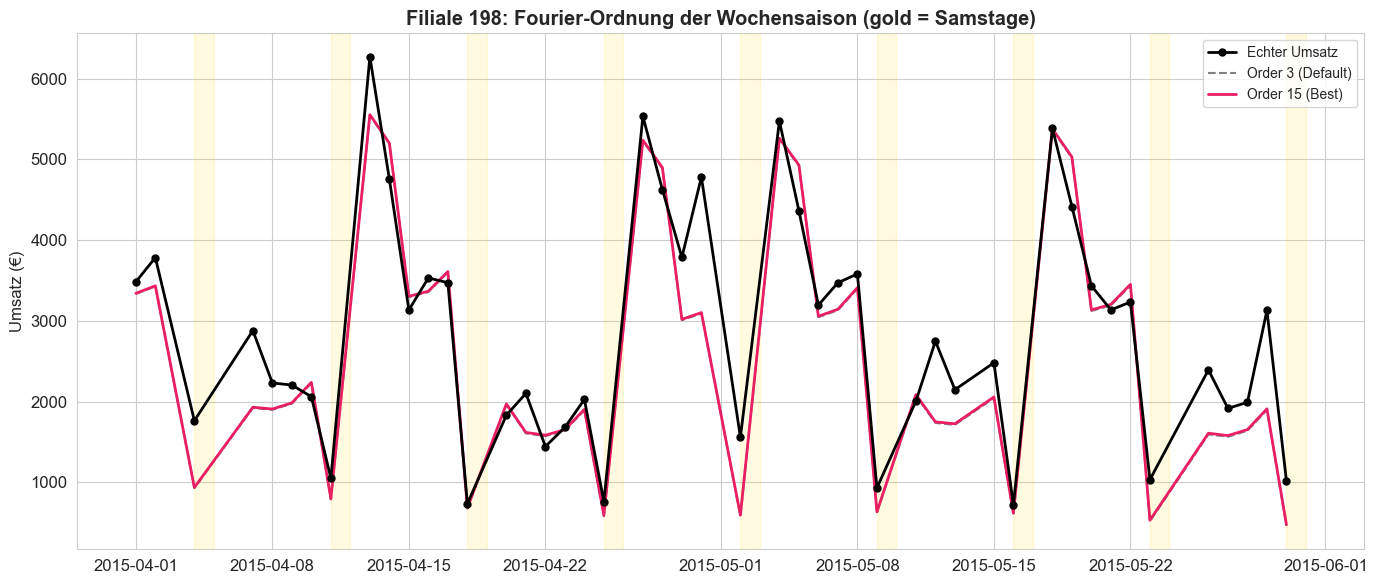


💡 Beste Fourier-Ordnung: 15
   Achte besonders auf die RMSPE-Samstag-Spalte – dort sollte sich der größte Effekt zeigen.


In [31]:
# === OPTION B: Wochensaisonalität verfeinern (höhere Fourier-Ordnung) ===
# Hypothese: Default weekly_seasonality (~3 Fourier-Terme) ist zu glatt für den
# scharfen Samstag-Einbruch (933€ vs. 4161€ Montag). Mehr Terme = schärfere Kurve.

# Wir bauen auf Modell B auf (Promo × Wochentag), variieren nur die Fourier-Ordnung
results_fourier = {}

for fourier_order in [3, 6, 10, 15]:
    m = Prophet(holidays=holidays_baseline,
                yearly_seasonality=True,
                weekly_seasonality=fourier_order,   # <-- der getestete Parameter
                interval_width=0.80)
    m.add_regressor('promo_frueh', mode='additive', prior_scale=10)
    m.add_regressor('promo_spaet', mode='additive', prior_scale=10)
    m.fit(train_feat[['ds', 'y', 'promo_frueh', 'promo_spaet']])
    fc = m.predict(test_feat[['ds', 'promo_frueh', 'promo_spaet']])
    
    # Metriken: gesamt, nur Samstage, nur Promo-Tage
    sa_mask    = df_test_198['Date'].dt.dayofweek.values == 5
    promo_mask = df_test_198['Promo'].values == 1
    results_fourier[fourier_order] = {
        'RMSPE_gesamt': rmspe(y_true, fc['yhat'].values),
        'RMSPE_samstag': rmspe(y_true[sa_mask], fc['yhat'].values[sa_mask]),
        'RMSPE_promo': rmspe(y_true[promo_mask], fc['yhat'].values[promo_mask]),
        'MAE': mean_absolute_error(y_true, fc['yhat'].values),
        'forecast': fc
    }

# Vergleichstabelle
print("Einfluss der Fourier-Ordnung (Wochensaisonalität):")
print(f"{'Order':>6} | {'RMSPE ges.':>10} | {'RMSPE Sa':>9} | {'RMSPE Promo':>11} | {'MAE':>7}")
print("-" * 55)
for order, r in results_fourier.items():
    print(f"{order:>6} | {r['RMSPE_gesamt']:>9.1f}% | {r['RMSPE_samstag']:>8.1f}% | "
          f"{r['RMSPE_promo']:>10.1f}% | {r['MAE']:>6.0f}€")

# Bester vs. schlechtester im Plot
best_order  = min(results_fourier, key=lambda k: results_fourier[k]['RMSPE_gesamt'])
fc_best = results_fourier[best_order]['forecast']
fc_def  = results_fourier[3]['forecast']

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_test_198['Date'], y_true, 'o-', color='black', markersize=5,
        label='Echter Umsatz', linewidth=2, zorder=5)
ax.plot(fc_def['ds'], fc_def['yhat'], '--', color='gray',
        linewidth=1.5, label='Order 3 (Default)')
ax.plot(fc_best['ds'], fc_best['yhat'], '-', color='#E91E63',
        linewidth=2, label=f'Order {best_order} (Best)')
# Samstage markieren
for d in df_test_198[df_test_198['Date'].dt.dayofweek == 5]['Date']:
    ax.axvspan(d, d + pd.Timedelta(days=1), alpha=0.12, color='gold')
ax.set_title(f'Filiale {STORE_PROMO}: Fourier-Ordnung der Wochensaison (gold = Samstage)',
             fontweight='bold')
ax.set_ylabel('Umsatz (€)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print()
print(f'💡 Beste Fourier-Ordnung: {best_order}')
print('   Achte besonders auf die RMSPE-Samstag-Spalte – dort sollte sich der größte Effekt zeigen.')

12:44:51 - cmdstanpy - INFO - Chain [1] start processing
12:44:51 - cmdstanpy - INFO - Chain [1] done processing


Vergleich: Promo als Holiday vs. Promo als Regressor (Wochentag-Interaktion)
Modell                         | RMSPE ges. |  RMSPE Sa | RMSPE Promo |     MAE
------------------------------------------------------------------------
Promo als Holiday              |      24.2% |     34.6% |       12.0% |    449€
Promo als Regressor (B)        |      22.9% |     39.9% |       11.5% |    403€


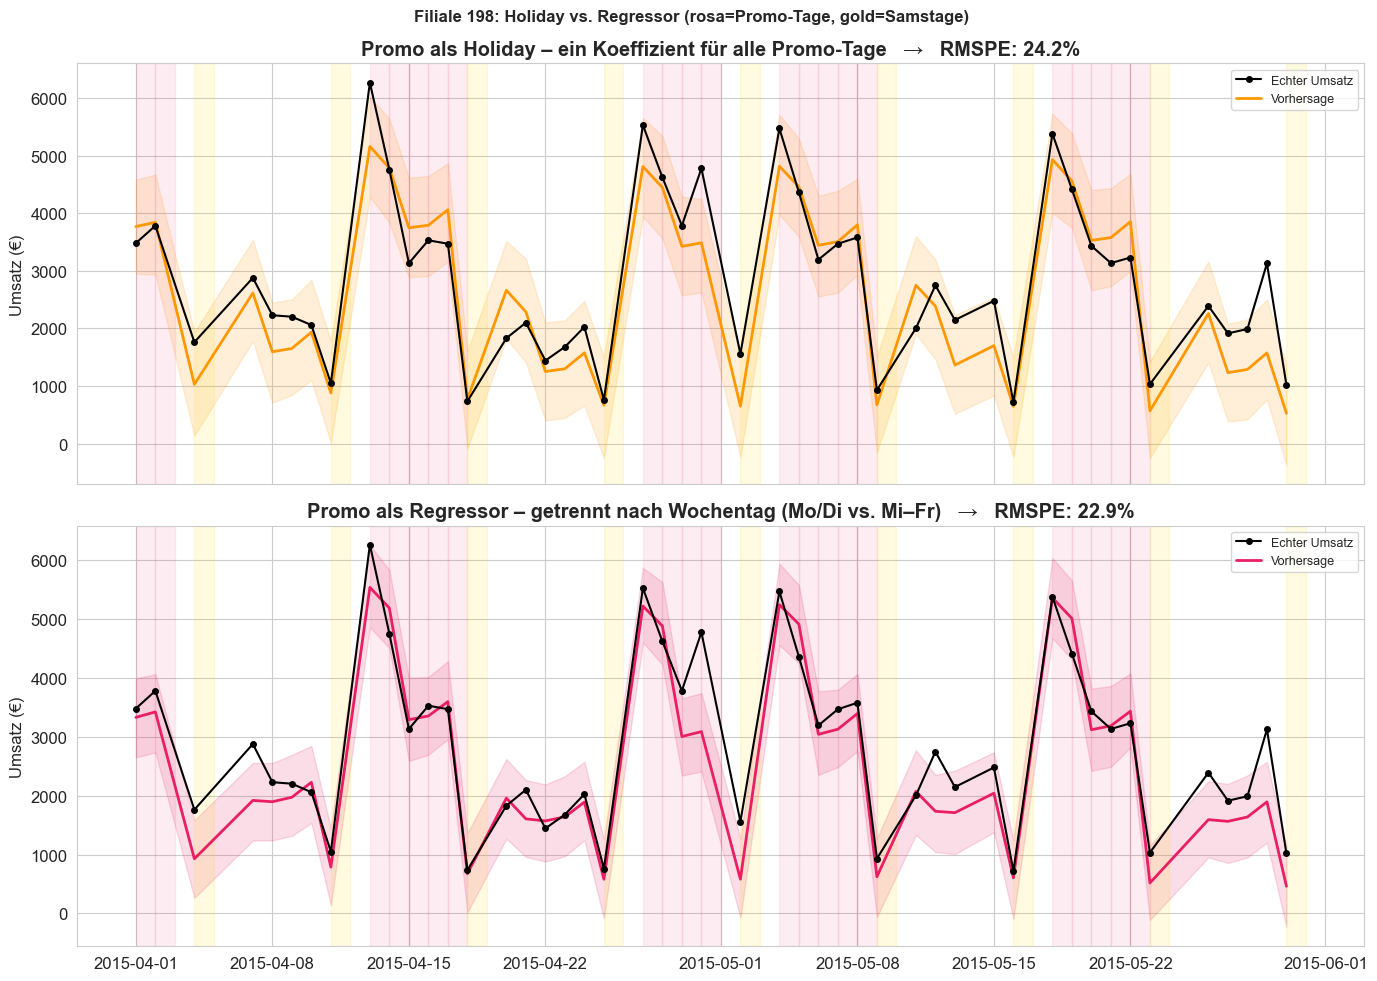


💡 Key Message:
   Holiday lernt EINEN Promo-Koeffizienten → unterschätzt Mo/Di, überschätzt Fr
   Regressor mit Wochentag-Interaktion lernt TWO Koeffizienten:
   promo_frueh (Mo/Di): +3.335€  |  promo_spaet (Mi–Fr): +1.475€

   Weder Holiday noch Regressor behebt die Samstag-Unterschätzung –
   dort liegt der verbleibende Fehler, unabhängig vom Promo-Modell.


In [32]:
# === VERGLEICH: Promo als Holiday vs. Promo als Regressor (Wochentag-Interaktion) ===
# Fourier-Ordnung brachte keinen Unterschied → wir vergleichen stattdessen
# die zwei grundlegenden Modellierungsansätze für Promo direkt.

# --- Modell Holiday: alle Promo-Tage als ein einziger Holiday-Typ ---
promo_holiday_df = df_198[df_198['Promo'] == 1][['Date']].rename(columns={'Date': 'ds'})
promo_holiday_df['holiday'] = 'promo'
holidays_mit_promo = pd.concat([holidays_baseline, promo_holiday_df], ignore_index=True)

m_holiday = Prophet(holidays=holidays_mit_promo, yearly_seasonality=True,
                    weekly_seasonality=True, interval_width=0.80)
m_holiday.fit(p_train_198)
fc_holiday = m_holiday.predict(p_test_198[['ds']])

# --- Modell Regressor B: Promo × Wochentag (bereits berechnet als fcB) ---
# fcB ist aus der vorherigen Zelle bereits vorhanden

# Masken
sa_mask    = df_test_198['Date'].dt.dayofweek.values == 5
promo_mask = df_test_198['Promo'].values == 1
kein_promo = df_test_198['Promo'].values == 0

# Vergleichstabelle
print("Vergleich: Promo als Holiday vs. Promo als Regressor (Wochentag-Interaktion)")
print(f"{'Modell':<30} | {'RMSPE ges.':>10} | {'RMSPE Sa':>9} | {'RMSPE Promo':>11} | {'MAE':>7}")
print("-" * 72)
for label, fc in [
    ('Promo als Holiday        ', fc_holiday),
    ('Promo als Regressor (B)  ', fcB),
]:
    print(f"{label:<30} | "
          f"{rmspe(y_true, fc['yhat'].values):>9.1f}% | "
          f"{rmspe(y_true[sa_mask], fc['yhat'].values[sa_mask]):>8.1f}% | "
          f"{rmspe(y_true[promo_mask], fc['yhat'].values[promo_mask]):>10.1f}% | "
          f"{mean_absolute_error(y_true, fc['yhat'].values):>6.0f}€")

# Plot: beide Modelle + Echter Umsatz
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
for ax, (label, fc, color) in zip(axes, [
    ('Promo als Holiday – ein Koeffizient für alle Promo-Tage', fc_holiday, '#FF9800'),
    ('Promo als Regressor – getrennt nach Wochentag (Mo/Di vs. Mi–Fr)', fcB, '#E91E63'),
]):
    ax.plot(df_test_198['Date'], y_true, 'o-', color='black', markersize=4,
            label='Echter Umsatz', linewidth=1.5, zorder=5)
    ax.plot(fc['ds'], fc['yhat'], '-', color=color, linewidth=2, label='Vorhersage')
    ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'], alpha=0.15, color=color)
    # Promo-Tage markieren
    for d in df_test_198[df_test_198['Promo'] == 1]['Date']:
        ax.axvspan(d, d + pd.Timedelta(days=1), alpha=0.08, color='#E91E63')
    # Samstage markieren
    for d in df_test_198[df_test_198['Date'].dt.dayofweek == 5]['Date']:
        ax.axvspan(d, d + pd.Timedelta(days=1), alpha=0.12, color='gold')
    rmspe_val = rmspe(y_true, fc['yhat'].values)
    ax.set_title(f'{label}   →   RMSPE: {rmspe_val:.1f}%', fontweight='bold')
    ax.set_ylabel('Umsatz (€)')
    ax.legend(fontsize=9)

plt.suptitle(f'Filiale {STORE_PROMO}: Holiday vs. Regressor (rosa=Promo-Tage, gold=Samstage)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print()
print('💡 Key Message:')
print('   Holiday lernt EINEN Promo-Koeffizienten → unterschätzt Mo/Di, überschätzt Fr')
print('   Regressor mit Wochentag-Interaktion lernt TWO Koeffizienten:')
print(f'   promo_frueh (Mo/Di): +3.335€  |  promo_spaet (Mi–Fr): +1.475€')
print()
print('   Weder Holiday noch Regressor behebt die Samstag-Unterschätzung –')
print('   dort liegt der verbleibende Fehler, unabhängig vom Promo-Modell.')

### 💡 Deep Dive: Warum Regressoren mächtiger sind als Holidays für steuerbare Effekte

Wir erinnern uns an die Prophet-Gleichung vom Anfang: $y(t) = \dots + h(t) + \beta X(t) + \epsilon_t$

Beide Ansätze können theoretisch den Promo-Effekt abbilden, aber sie tun es mathematisch grundlegend anders:

* **Der Holiday-Ansatz ($h(t)$):** Behandelt jeden Promo-Tag als ein isoliertes "Schock-Event". Prophet schaut nur: *War an dem Tag Promo? Ja/Nein.* Bei sehr vielen Promo-Tagen wird das Modell unübersichtlich und läuft Gefahr, Einzelereignisse überzubewerten.
* **Der Regressor-Ansatz ($\beta X(t)$):** Prophet lernt einen festen, globalen Koeffizienten $\beta$ über den gesamten Zeitraum. Nimmt die Promo-Variable $X(t)$ den Wert 1 an, wird $\beta$ angewendet. Da wir hier `mode='multiplicative'` gewählt haben, skaliert der Regressor den Basis-Umsatz prozentual (hier um satte +145%). 

**Wann nutze ich was in der Praxis?**
| Typ | Holiday | Regressor (`add_regressor`) |
|---|---|---|
| **Einsatzgebiet** | Punktuelle, kalenderbasierte Events | Wiederkehrende, steuerbare Variablen |
| **Beispiele** | Ostern, Weihnachten, Stadtfest | Promotionen, Werbebudget, Preis, Wetter |
| **Wertebereich** | Binär (Event findet statt oder nicht) | Kontinuierlich möglich (z.B. Rabatt in % oder °C) |
| **Vorteil** | Flexibel für einzelne Ausreißer | Robuster, besser interpretierbar, verarbeitet auch Zahlenwerte |

---

## 📏 6. Fazit: Der Analyst als entscheidender Faktor

Was können wir aus dieser Demo mitnehmen?

1. **Kontext schlägt Algorithmus:** Ein generisches "Out-of-the-Box"-Modell übersieht lokale Realitäten. Derselbe Feiertag (1. Mai) bedeutet für eine Stadtfiliale `-100%` Umsatz, für den Ferienort aber `+385%`. 
2. **Unsichtbare Muster aufdecken:** Effekte wie der Shopping-Boom am Ostersamstag sind in der reinen `StateHoliday`-Spalte des Datensatzes schlichtweg **nicht vorhanden**. Nur durch Explorative Datenanalyse (EDA) und Domänenwissen können wir sie einbauen.
3. **Das richtige Werkzeug wählen:** Holidays für punktuelle Ausreißer, Regressoren für systematische Treiber wie Promotionen.

Der **Analyst-in-the-Loop** ist kein Relikt aus der Vor-KI-Zeit – er ist das entscheidende Element, um aus einem mathematisch korrekten Modell ein geschäftlich *sinnvolles* Modell zu machen.

---
## 🦢 7. Der Strukturbruch: Wenn Saisonalität auf die Realität prallt

**Das Szenario:** Wir haben fantastische, saubere Flugdaten für das gesamte Jahr 2019 bis Ende Februar 2020. Wir können wöchentliche Muster und Feiertags-Peaks perfekt ablesen. Wir stehen am **1. März 2020** und sollen den Frühling prognostizieren. 

**Das Problem:** Klassische Modelle wie Prophet sind hervorragend darin, die Vergangenheit zu lernen und Saisonalitäten fortzuschreiben. Aber sie haben keine "Sensoren" für externe Schocks. Schauen wir uns an, was passiert, wenn ein Modell, das auf eine normale Welt trainiert wurde, auf die COVID-19-Pandemie trifft.

The last date in the dataset is: 2022-05-31


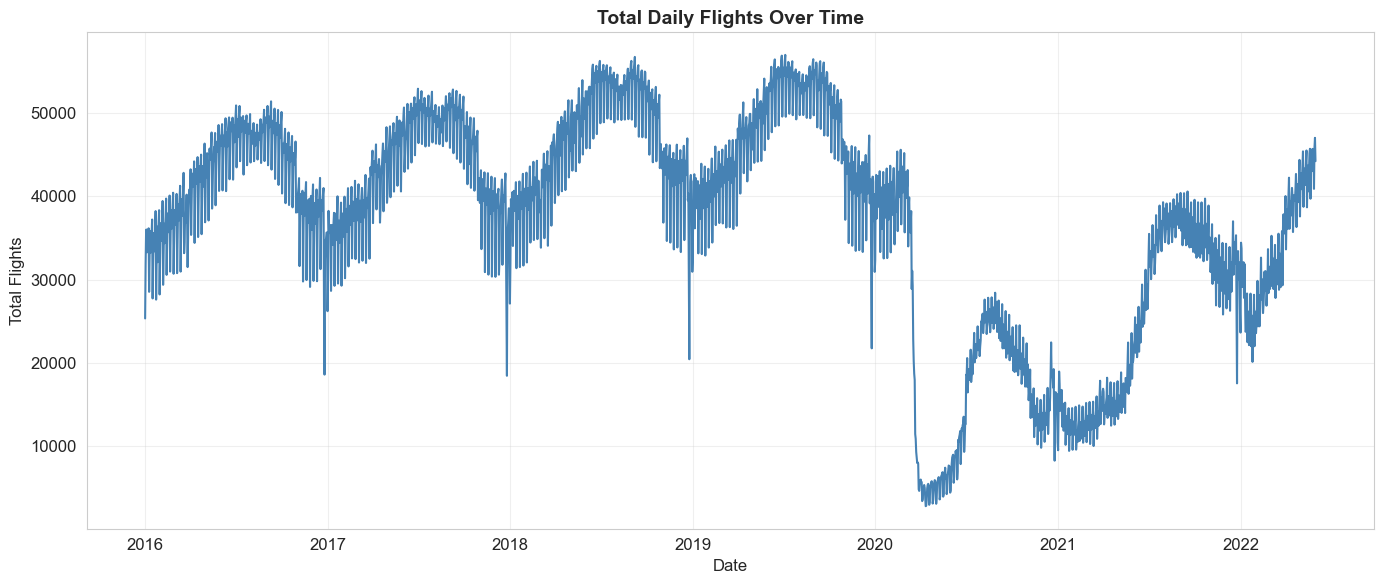

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset (ensure the filename matches exactly)
# We use parse_dates to automatically convert the FLT_DATE column to datetime objects
df = pd.read_csv('../data/flights.csv', parse_dates=['FLT_DATE'])

# 2. Find and print the last date in the dataset
last_date = df['FLT_DATE'].max()
print(f"The last date in the dataset is: {last_date.date()}")

# 3. Prepare the data for plotting
# Since the data has multiple airports per day, we need to sum them up to get a daily total
daily_flights = df.groupby('FLT_DATE')['FLT_TOT_1'].sum().reset_index()

# 4. Plot the flight numbers
plt.figure(figsize=(14, 6))
plt.plot(daily_flights['FLT_DATE'], daily_flights['FLT_TOT_1'], color='steelblue', linewidth=1.5)

# Formatting the plot
plt.title('Total Daily Flights Over Time', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Flights', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()

In [49]:
print(list(df.columns))

['YEAR', 'MONTH_NUM', 'MONTH_MON', 'FLT_DATE', 'APT_ICAO', 'APT_NAME', 'STATE_NAME', 'FLT_DEP_1', 'FLT_ARR_1', 'FLT_TOT_1', 'FLT_DEP_IFR_2', 'FLT_ARR_IFR_2', 'FLT_TOT_IFR_2', 'Pivot Label']


---
## ✈️ 7. Prophet im Stresstest: Saisonalität vs. "Black Swan"

Wir nutzen nun echte europäische Flugbewegungsdaten, um Prophet einem finalen Test zu unterziehen. Wir teilen das Experiment in zwei Phasen auf:

1. **Die "heile Welt" (2016-2018):** Wir trainieren Prophet auf 2016 und 2017 und lassen das Modell das Jahr 2018 vorhersagen. Hier erwarten wir, dass Prophet glänzt.
2. **Der Black Swan (2018-2020):** Wir trainieren Prophet auf 2018 und 2019 und prognostizieren das Jahr 2020. Hier trifft mathematisches Curve-Fitting auf den globalen COVID-19-Lockdown.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

# 1. Daten laden und für Prophet aufbereiten
print("Lade Flugdaten...")
df = pd.read_csv('flights.csv', parse_dates=['FLT_DATE'])

# Wir summieren alle Flughäfen pro Tag zusammen
daily_flights = df.groupby('FLT_DATE')['FLT_TOT_1'].sum().reset_index()

# Prophet Format: 'ds' für Datum, 'y' für Zielwert
daily_flights = daily_flights.rename(columns={'FLT_DATE': 'ds', 'FLT_TOT_1': 'y'})

# WICHTIG: Zeitzonen-Infos entfernen, da Prophet reine Datumsformate bevorzugt
if daily_flights['ds'].dt.tz is not None:
    daily_flights['ds'] = daily_flights['ds'].dt.tz_localize(None)

print("✅ Daten erfolgreich aufbereitet!")

Lade Flugdaten...
✅ Daten erfolgreich aufbereitet!


In [51]:
# --- PHASE 1: Vorhersage 2018 (Trainiert auf 2016-2017) ---
print("Trainiere Modell 1: Normales Jahr (2018)...")

# Datensplits
train_2016_2017 = daily_flights[(daily_flights['ds'].dt.year >= 2016) & (daily_flights['ds'].dt.year <= 2017)]
test_2018 = daily_flights[daily_flights['ds'].dt.year == 2018]

# Prophet trainieren
m_normal = Prophet(yearly_seasonality=True, weekly_seasonality=True)
m_normal.fit(train_2016_2017)
fc_2018 = m_normal.predict(test_2018[['ds']])

print("✅ Vorhersage für 2018 abgeschlossen!")

13:09:06 - cmdstanpy - INFO - Chain [1] start processing
13:09:06 - cmdstanpy - INFO - Chain [1] done processing


Trainiere Modell 1: Normales Jahr (2018)...
✅ Vorhersage für 2018 abgeschlossen!


In [52]:
# --- PHASE 2: Vorhersage 2020 (Trainiert auf 2018-2019) ---
print("Trainiere Modell 2: Krisenjahr (2020)...")

# Datensplits
train_2018_2019 = daily_flights[(daily_flights['ds'].dt.year >= 2018) & (daily_flights['ds'].dt.year <= 2019)]
test_2020 = daily_flights[daily_flights['ds'].dt.year == 2020]

# Prophet trainieren
m_covid = Prophet(yearly_seasonality=True, weekly_seasonality=True)
m_covid.fit(train_2018_2019)
fc_2020 = m_covid.predict(test_2020[['ds']])

print("✅ Vorhersage für 2020 abgeschlossen!")

13:09:13 - cmdstanpy - INFO - Chain [1] start processing
13:09:13 - cmdstanpy - INFO - Chain [1] done processing


Trainiere Modell 2: Krisenjahr (2020)...
✅ Vorhersage für 2020 abgeschlossen!


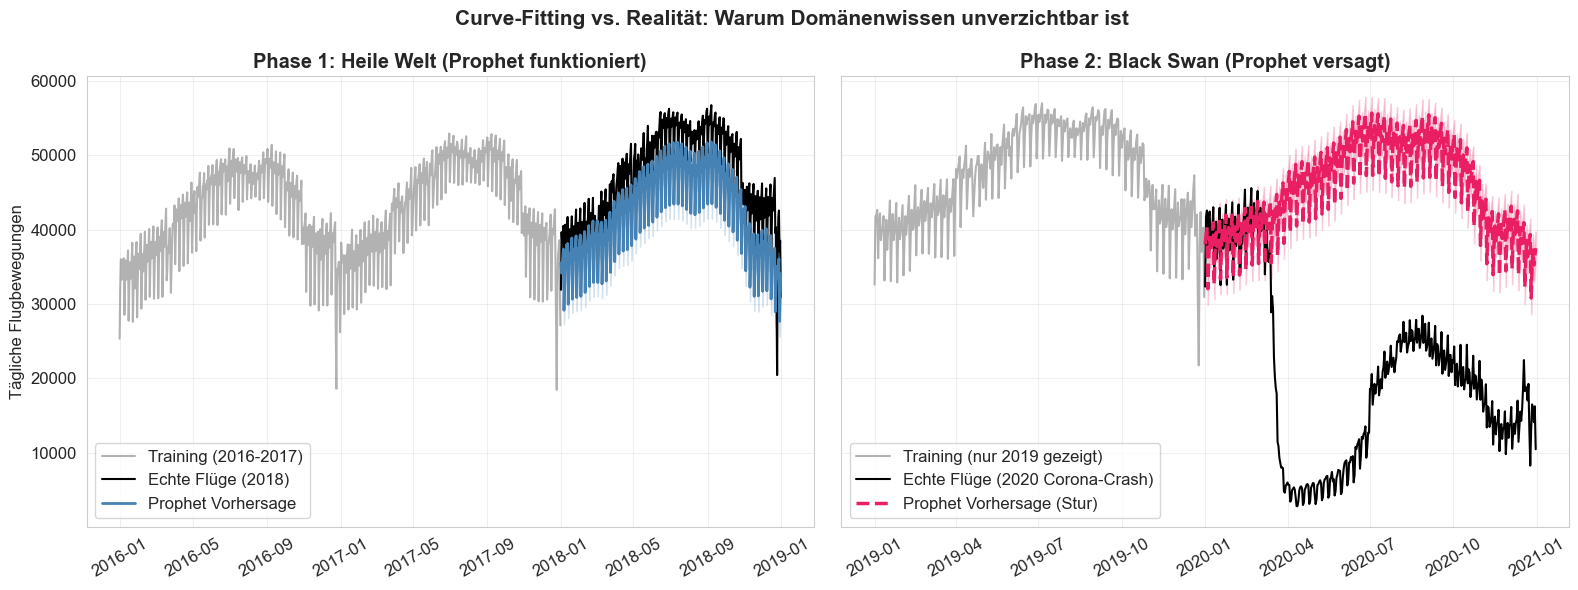

In [53]:
# Visualisierung: Der große Vergleich
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# ---------------------------------------------------------
# Plot 1: Der Erfolg (2018)
# ---------------------------------------------------------
axes[0].plot(train_2016_2017['ds'], train_2016_2017['y'], color='gray', alpha=0.6, label='Training (2016-2017)')
axes[0].plot(test_2018['ds'], test_2018['y'], color='black', markersize=3, label='Echte Flüge (2018)')
axes[0].plot(fc_2018['ds'], fc_2018['yhat'], color='steelblue', linewidth=2, label='Prophet Vorhersage')
axes[0].fill_between(fc_2018['ds'], fc_2018['yhat_lower'], fc_2018['yhat_upper'], alpha=0.2, color='steelblue')

axes[0].set_title('Phase 1: Heile Welt (Prophet funktioniert)', fontweight='bold')
axes[0].set_ylabel('Tägliche Flugbewegungen')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.3)

# ---------------------------------------------------------
# Plot 2: Das Scheitern (2020)
# ---------------------------------------------------------
# Wir zoomen hier etwas rein (nur 2019 im Training anzeigen), damit der Absturz dramatischer wirkt
train_2019_only = train_2018_2019[train_2018_2019['ds'].dt.year == 2019]

axes[1].plot(train_2019_only['ds'], train_2019_only['y'], color='gray', alpha=0.6, label='Training (nur 2019 gezeigt)')
axes[1].plot(test_2020['ds'], test_2020['y'], color='black', markersize=3, label='Echte Flüge (2020 Corona-Crash)')
axes[1].plot(fc_2020['ds'], fc_2020['yhat'], color='#E91E63', linestyle='--', linewidth=2.5, label='Prophet Vorhersage (Stur)')
axes[1].fill_between(fc_2020['ds'], fc_2020['yhat_lower'], fc_2020['yhat_upper'], alpha=0.2, color='#E91E63')

axes[1].set_title('Phase 2: Black Swan (Prophet versagt)', fontweight='bold')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curve-Fitting vs. Realität: Warum Domänenwissen unverzichtbar ist', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 🚀 Phase 3: Die Rettung durch Chronos (Foundation Model)

Wenn mathematisches "Curve Fitting" (Prophet) an einem Black Swan Event scheitert, brauchen wir ein Modell mit "Weltwissen". 

**Chronos (von Amazon)** ist ein Zero-Shot Foundation Model für Zeitreihen. Es behandelt unsere historischen Flugdaten wie einen Text-Prompt. Es kennt keinen Kalender, aber es hat aus Milliarden von Trainings-Zeitreihen gelernt, wie sich reale Metriken verhalten (z.B. dass ein Absturz irgendwann abflacht und nicht endlos weitergeht).

*(Hinweis: Erfordert die Installation via `!pip install git+https://github.com/amazon-science/chronos-forecasting.git`)*

1. Generiere Test-Daten (Sinuskurve)...
2. Lade Chronos Modell (tiny-Version für maximalen Speed)...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


3. Generiere Vorhersage...
✅ Vorhersage erfolgreich! Output Shape: torch.Size([1, 5, 24])
4. Plotte das Ergebnis...


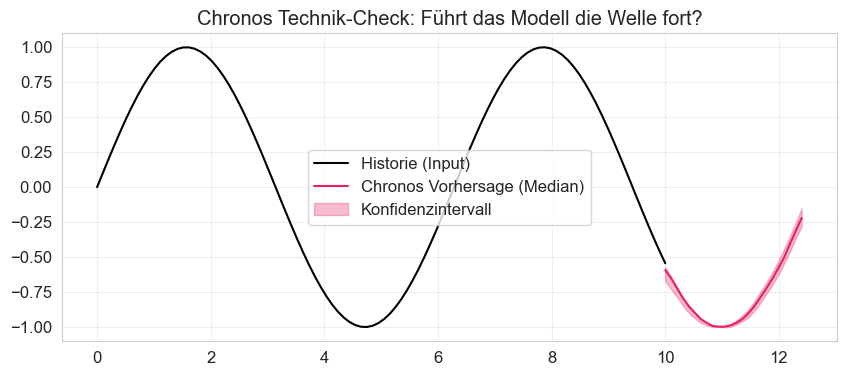

🎉 Wenn du diesen Plot siehst, ist dein Environment perfekt eingerichtet!


In [56]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from chronos import ChronosPipeline

print("1. Generiere Test-Daten (Sinuskurve)...")
# Wir erstellen 100 Datenpunkte einer simplen Sinuskurve
t_past = np.linspace(0, 10, 100)
context_data = np.sin(t_past)
context_tensor = torch.tensor(context_data)

print("2. Lade Chronos Modell (tiny-Version für maximalen Speed)...")
# 'tiny' ist extrem klein und lädt in Sekunden herunter - ideal für einen Technik-Check
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny", 
    device_map="cpu", 
    torch_dtype=torch.bfloat16,
)

print("3. Generiere Vorhersage...")
# Wir wollen 24 Schritte in die Zukunft schauen, mit nur 5 Samples (geht superschnell)
prediction_length = 24
forecast = pipeline.predict(context_tensor, prediction_length=prediction_length, num_samples=5)

# Forecast-Tensor hat die Form [batch_size, num_samples, prediction_length]
print(f"✅ Vorhersage erfolgreich! Output Shape: {forecast.shape}")

print("4. Plotte das Ergebnis...")
low, median, high = np.quantile(forecast[0].numpy(), [0.1, 0.5, 0.9], axis=0)

t_future = np.linspace(10, 10 + (10/100)*prediction_length, prediction_length)

plt.figure(figsize=(10, 4))
plt.plot(t_past, context_data, color="black", label="Historie (Input)")
plt.plot(t_future, median, color="#E91E63", label="Chronos Vorhersage (Median)")
plt.fill_between(t_future, low, high, color="#E91E63", alpha=0.3, label="Konfidenzintervall")
plt.title("Chronos Technik-Check: Führt das Modell die Welle fort?")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("🎉 Wenn du diesen Plot siehst, ist dein Environment perfekt eingerichtet!")